<a href="https://colab.research.google.com/github/Harsh-SOE/SSNeRF/blob/main/SSNeRF_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Harsh-SOE/SSNeRF.git
!cd SSNeRF 

<div style="width: 100%;">
  <h1><tt>Semantic and Silhouette Guided Neural Radiance Fields</tt></h1>
  <p><i>Reconstruction of 3D model from sparse multi-view dataset.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p>This interactive notebook delve into the world of <b>Neural Radiance Fields (NeRF)</b> applied to botany. We'll transform a series of 2D images of a plant into a detailed 3D model, complete with semantic segmentation.</p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

<div style="width: 100%;">
  <h3><tt>Environment Setup and Dependencies</tt></h3>
  <p><i>Verifying CUDA availability and installing necessary libraries for NeRF and semantic segmentation.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [1]:
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Thu May 14 07:56:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q segment-anything open3d trimesh scikit-image scipy tqdm albumentations scikit-learn networkx
!pip install -q matplotlib opencv-python-headless timm fast-simplification ExifRead
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!pip install rembg[gpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 94.8 MB/s eta 0

<div style="width: 100%;">
  <h3><tt>Importing neccessary packages and additional configuation</tt></h3>
</div>

In [ ]:
try:
  import os, math, json, time, zipfile, warnings, exifread, random, shutil
  import numpy as np
  import sys
  import cv2
  import torch
  import torch.nn as nn
  import matplotlib.pyplot as plt
  import matplotlib.patches as mpatches
  import networkx as nx
  import albumentations as A
  from dataclasses import dataclass, field
  import torch.nn.functional as F
  from torch.utils.data import Dataset, DataLoader
  from pathlib import Path
  from tqdm import tqdm
  from scipy.optimize import curve_fit
  from skimage import measure
  from albumentations.pytorch import ToTensorV2
  from PIL import Image
  from skimage.morphology import skeletonize, binary_dilation, disk
  from skimage.measure   import label as cc_label
  from scipy.ndimage     import binary_fill_holes
  from rembg import remove as rembg_remove, new_session
  from typing import Dict, Tuple, Any
  from google.colab import files
except ImportError as e:
    print(f"Import error: {e}")

warnings.filterwarnings("ignore")

<div style="width: 100%;">
  <h2><tt>Configuration </tt></h2>
</div>

<div style="width: 100%;">
  <h3><tt>Directory setup</tt></h3>
</div>

In [ ]:
BASE_DIR      = Path('/content/plant_nerf')
RAW_DIR       = BASE_DIR / 'images_raw'
ALIGNED_RAW_DIR = BASE_DIR / 'images_raw_axis_aligned'
AXIS_DEBUG_DIR  = BASE_DIR / 'axis_debug'
SEGMENTED_DIR = BASE_DIR / 'images_segmented'
RESIZED_DIR   = BASE_DIR / 'images_resized'
MASK_DIR      = BASE_DIR / 'masks'
MASK_VIS_DIR  = BASE_DIR / 'masks_vis'
LABEL_DIR     = BASE_DIR / 'labels'
LABEL_VIS_DIR = BASE_DIR / 'labels_vis'
CKPT_DIR      = BASE_DIR / 'checkpoints'
OUTPUT_DIR    = BASE_DIR / 'output'
DEBUG_DIR     = BASE_DIR / 'debug'

for d in [RAW_DIR,
          RESIZED_DIR,
          ALIGNED_RAW_DIR,
          AXIS_DEBUG_DIR,
          MASK_DIR,
          MASK_VIS_DIR,
          LABEL_DIR,
          LABEL_VIS_DIR,
          CKPT_DIR,
          OUTPUT_DIR,
          SEGMENTED_DIR,
          DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

<div style="width: 100%;">
  <h3><tt>Camera Config</tt></h3>
</div>

In [ ]:
@dataclass
class CameraConfig:
    resized_w: int = 400
    resized_h: int = 533

    focal_length_mm: float = 5.58
    sensor_width_mm: float = 5.52 # 1/1.73" sensor width when shooting in portrait mode

    camera_radius = 2.5

    @property
    def focal_length(self) -> float:
        """
        Calculates focal length in pixels using physical camera specs.
        Formula: f_px = f_mm * (image_width_px / sensor_width_mm)
        """
        return self.focal_length_mm * (self.resized_w / self.sensor_width_mm)

    @property
    def fov_x_deg(self) -> float:
        """Horizontal Field of View in degrees"""
        return 2 * math.degrees(math.atan(self.resized_w / 2 / self.focal_length))

    @property
    def fov_y_deg(self) -> float:
        """Vertical Field of View in degrees"""
        return 2 * math.degrees(math.atan(self.resized_h / 2 / self.focal_length))

    @property
    def nerf_intrinsics(self) -> Dict[str, Any]:
        """
        Outputs the exact parameters needed for standard NeRF transforms.json files.
        (Omitted camera angles as fl_x and fl_y are sufficient and mathematically superior).
        """
        f = round(self.focal_length, 2)
        return {
            "fl_x": f,
            "fl_y": f,
            "cx": self.resized_w / 2.0,
            "cy": self.resized_h / 2.0,
            "w": self.resized_w,
            "h": self.resized_h
        }

<div style="width: 100%;">
  <h3><tt>TurnTable Config</tt></h3>
</div>

In [ ]:
@dataclass
class TurnTableConfig:
    angle_period: int = 18

    use_top_view: bool = False

    @property
    def rotation_angles(self):
        return list(range(0, 360, self.angle_period))

    @property
    def num_images(self):
        return len(self.rotation_angles)

<div style="width: 100%;">
  <h3><tt>Semantics Config</tt></h3>
</div>

In [ ]:
@dataclass
class SemanticConfig:
    num_classes: int = 5

    class_names: dict = field(default_factory=lambda: {
        0: 'background',
        1: 'leaf',
        2: 'stem',
        3: 'petiole',
        4: 'apex'
    })

    class_colors_bgr: dict = field(default_factory=lambda: {
        0:(0,0,0),
        1:(0,200,0),
        2:(0,140,255),
        3:(0,255,255),
        4:(0,0,200)
    })

    class_weights: torch.Tensor = field(
        default_factory=lambda: torch.tensor([0.2, 1.0, 4.0, 3.0, 6.0])
    )

<div style="width: 100%;">
  <h3><tt>Training Config</tt></h3>
</div>

In [ ]:
@dataclass
class TrainingConfig:
    near: float = 1.5
    far: float = 4.0

    n_samples_coarse: int = 48
    n_samples_fine: int = 128

    batch_rays: int = 4096
    num_iters: int = 10_000

    lr: float = 3e-4
    pose_lr: float = 1e-3

    use_amp: bool = True

    lambda_sil: float = 1.0
    lambda_sem: float = 0.1
    lambda_pose: float = 0.01
    lambda_bg_acc: float = 1.0
    lambda_dist: float = 0.02

    color_ramp_iters: int = 3000

    sil_decay_start_pct: float = 0.7

    enable_sem: bool = True
    sem_start_iters: int = 7500
    sem_ramp_iters: int = 1000

    enable_top_view_refinement: bool = True
    top_view_start_iter: int = 3750
    top_view_pose_ramp_iters: int = 500

    enable_pose_refinement: bool = True
    pose_start_iter: int = 3750
    pose_ramp_iters: int = 1000

    log_every: int = 200
    save_every: int = 500

<div style="width: 100%;">
  <h3><tt>Project Config</tt></h3>
</div>

In [ ]:
@dataclass
class Config:
    camera: CameraConfig = field(default_factory=CameraConfig)
    rotation: TurnTableConfig = field(default_factory=TurnTableConfig)
    training: TrainingConfig = field(default_factory=TrainingConfig)
    semantic: SemanticConfig = field(default_factory=SemanticConfig)

    sam_checkpoint: str = '/content/sam_vit_h_4b8939.pth'

    density_threshold: float = 12
    plant_bound: float = 0.8
    grid_res: int = 512

    device: torch.device = field(
        default_factory=lambda: torch.device(
            'cuda' if torch.cuda.is_available() else 'cpu'
        )
    )

In [ ]:
cfg = Config()

In [ ]:
print(f"Focal Length (px): {cfg.camera.focal_length:.1f}")
print(f"FOV X: {cfg.camera.fov_x_deg:.1f}° | FOV Y: {cfg.camera.fov_y_deg:.1f}°")

print("\nNeRF transforms.json parameters:")
for key, value in cfg.camera.nerf_intrinsics.items():
  # Format floating points for cleaner output
  val_str = f"{value:.4f}" if isinstance(value, float) else value
  print(f"  {key}: {val_str}")

Focal Length (px): 404.3
FOV X: 52.6° | FOV Y: 66.8°

NeRF transforms.json parameters:
  fl_x: 404.3500
  fl_y: 404.3500
  cx: 200.0000
  cy: 266.5000
  w: 400
  h: 533


<div style="width: 100%;">
  <h3><tt>Upload plant images </tt></h3>
</div>

In [ ]:
print(
    f"NOTE: You need to upload "
    f"{cfg.rotation.num_side_views_images} side views images in total "
    f"{'and 1 top view image as well' if cfg.rotation.use_top_view else ''}"
)

for angle in cfg.rotation.rotation_angles:
    print(f'Upload {int(angle/cfg.rotation.angle_period)}/{int(cfg.rotation.num_images)} image')
    image_new_name = f'{angle}.png'
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Please upload exactly one image.")
    image_original_name = next(iter(uploaded))
    src = Path(f"/content/{image_original_name}")
    dest = RAW_DIR / image_new_name
    shutil.move(str(src), str(dest))
    print(f'  Saved: {image_new_name}')

print(f"\n✅ All {cfg.rotation.num_images} images uploaded successfully!")

<div style="width: 100%;">
  <h3><tt>Mount from google drive </tt></h3>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DRIVE_DATASET_PATH = "/content/drive/MyDrive/Dataset"
!cp -r "{DRIVE_DATASET_PATH}/." "{RAW_DIR}/"

In [ ]:
for file_path in RAW_DIR.glob("*.jpg"):

    original_image_name_stem = file_path.stem
    original_image_name = file_path.name

    last = original_image_name_stem.split("_")[-1]

    if last == "top":
        print(f"Renamed \'{original_image_name}\' to \'top.png\'")
        new_name = "top.png"
        os.rename(os.path.join(RAW_DIR, original_image_name),os.path.join(RAW_DIR, new_name))
    else:
        angle = int(last)
        new_name = f"{angle * 18}.png"
        print(f"Renamed \'{original_image_name}\' to \'{new_name}\'")
        os.rename(os.path.join(RAW_DIR, file_path.name),os.path.join(RAW_DIR, new_name))

Renamed 'plant_angle_1.jpg' to '18.png'
Renamed 'plant_angle_12.jpg' to '216.png'
Renamed 'plant_angle_16.jpg' to '288.png'
Renamed 'plant_angle_11.jpg' to '198.png'
Renamed 'plant_angle_0.jpg' to '0.png'
Renamed 'plant_angle_2.jpg' to '36.png'
Renamed 'plant_angle_19.jpg' to '342.png'
Renamed 'plant_angle_13.jpg' to '234.png'
Renamed 'plant_angle_6.jpg' to '108.png'
Renamed 'plant_angle_4.jpg' to '72.png'
Renamed 'plant_angle_9.jpg' to '162.png'
Renamed 'plant_angle_top.jpg' to 'top.png'
Renamed 'plant_angle_10.jpg' to '180.png'
Renamed 'plant_angle_17.jpg' to '306.png'
Renamed 'plant_angle_18.jpg' to '324.png'
Renamed 'plant_angle_5.jpg' to '90.png'
Renamed 'plant_angle_8.jpg' to '144.png'
Renamed 'plant_angle_7.jpg' to '126.png'
Renamed 'plant_angle_14.jpg' to '252.png'
Renamed 'plant_angle_3.jpg' to '54.png'
Renamed 'plant_angle_15.jpg' to '270.png'


In [ ]:
def all_views():
    keys = list(cfg.rotation.rotation_angles)
    if (RAW_DIR / 'top.png').exists() and cfg.rotation.use_top_view == True:
        keys.append('top')
    return keys

def view_file_name(view_key):
    return f'{view_key}.png'

def view_label(view_key):
    return 'top' if view_key == 'top' else f'{view_key}°'

print(f'Total views: {all_views()}')

Total views: [0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342]


In [ ]:
def extract_focal_length_data(image_path: str):
    try:
        with open(image_path, 'rb') as f:
            tags = exifread.process_file(f)

        if not tags:
            print("No EXIF data found. (This image may have been resized, compressed, or stripped of metadata).")
            return

        make_tag = 'Image Make'
        model_tag = 'Image Model'
        focal_physical_tag = 'EXIF FocalLength'
        focal_35mm_tag = 'EXIF FocalLengthIn35mmFilm'

        if make_tag in tags and model_tag in tags:
            print(f"Camera Model: {tags[make_tag]} {tags[model_tag]}")
        else:
            print("Camera Model: Unknown")

        if focal_physical_tag in tags:
            phys_val = tags[focal_physical_tag]
            try:
                phys_float = float(eval(str(phys_val)))
                print(f"Physical Focal Length: {phys_float:.2f} mm")
            except:
                print(f"Physical Focal Length: {phys_val} mm")
        else:
            print("Physical Focal Length: NOT FOUND")

        if focal_35mm_tag in tags:
            print(f"35mm Equivalent: {tags[focal_35mm_tag]} mm")
        else:
            print("35mm Equivalent: NOT FOUND")

    except FileNotFoundError:
        print(f"Error: Could not find the file '{image_path}'. Check your path.")
    except Exception as e:
        print(f"An error occurred: {e}")

extract_focal_length_data('/content/plant_nerf/images_raw/0.png')

Camera Model: realme realme 7
Physical Focal Length: 5.58 mm
35mm Equivalent: 0 mm


<div style="width: 100%;">
  <h3><tt>Preprocessing</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Segmentation</i></p>
  <ol><i>
  <li>rembg  → strips black background (keeps plant + pot as RGBA)</li>
  <li>HSV filter → finds green/plant pixels to guide SAM</li>
  <li>Multi-point SAM → 8 positive (plant) + 4 negative (pot) prompts</li>
  <li>Best mask selection → SAM confidence + green pixel overlap</li>
  <li>Morphological refinement → closes leaf holes, fills thin stems</li>
  <li>Output → same resolution, non-plant pixels = black</li>
</ol></i>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [ ]:
def load_sam_predictor(checkpoint_path, device):
    from segment_anything import sam_model_registry, SamPredictor
    sam = sam_model_registry['vit_h'](checkpoint=checkpoint_path)
    sam.to(device)
    print("SAM-H loaded.")
    from segment_anything import SamPredictor
    return SamPredictor(sam)

In [ ]:
predictor = load_sam_predictor(cfg.sam_checkpoint, cfg.device)
print("SAM loaded successfully")

SAM-H loaded.
SAM loaded successfully


In [ ]:
@dataclass
class SAMConfig:
  positive_points: int = 8
  negative_points: int = 12

  hsv_lower: tuple[int, int, int] = (25, 25, 25)
  hsv_upper: tuple[int, int, int] = (95, 255, 255)

  save_debug: bool = True

In [ ]:
sam_cfg = SAMConfig()

In [ ]:
def rembg_foreground(image, session) -> np.ndarray:
    """
    STEP 1: Run rembg to remove the background.
    Returns boolean mask (H, W) — True = foreground (plant + pot).
    """
    result = rembg_remove(
        image,
        session                            = session,
        alpha_matting                      = True,
        alpha_matting_foreground_threshold = 240,
        alpha_matting_background_threshold = 20,
        alpha_matting_erode_size           = 7,
    )
    alpha  = np.array(result)[:, :, 3]
    return alpha > 10

def get_green_mask(img_rgb: np.ndarray, fg_mask: np.ndarray) -> np.ndarray:
    """
    Step 2: HSV-based green pixel detection, restricted to rembg foreground.
    Returns boolean mask (H, W).
    """
    hsv   = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower = np.array(sam_cfg.hsv_lower, dtype=np.uint8)
    upper = np.array(sam_cfg.hsv_upper, dtype=np.uint8)
    green = cv2.inRange(hsv, lower, upper).astype(bool)
    return green & fg_mask

def sample_points(mask: np.ndarray, n: int) -> np.ndarray:
    """
    Step 3 — Randomly sample n (x, y) coords from a boolean mask.
    Returns array of shape (k, 2) where k ≤ n.
    """
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return np.empty((0, 2), dtype=int)
    idx = np.random.choice(len(ys), min(n, len(ys)), replace=False)
    return np.column_stack([xs[idx], ys[idx]])

def sample_plant_points(green_mask: np.ndarray,
                        fg_mask: np.ndarray,
                        n: int) -> np.ndarray:
    """
    STEP 3 (a): Sample n positive SAM points from green pixels in the PLANT REGION only.
    Plant zone = top 70% of the foreground bounding box.
    Falls back to all green pixels if the plant zone is too sparse.
    """
    rows = np.where(fg_mask.any(axis=1))[0]
    if len(rows) == 0:
        return sample_points(green_mask, n)

    top, bottom  = rows[0], rows[-1]
    zone_bottom  = top + int((bottom - top) * 0.70)

    plant_zone_mask = np.zeros_like(fg_mask)
    plant_zone_mask[top:zone_bottom, :] = True

    zone_green = green_mask & plant_zone_mask

    if zone_green.sum() < 10:
        return sample_points(green_mask, n)

    return sample_points(zone_green, n)

def sample_non_plant_points(green_mask: np.ndarray,
                             fg_mask: np.ndarray,
                             img_rgb: np.ndarray,
                             n: int) -> np.ndarray:
    """
    STEP 3 (b): Sample negative SAM points from TWO regions:
      A) Bottom 35% of fg bbox  → pot/soil area
      B) Canopy gap pixels      → dark grey trapped between leaves

    Canopy gaps = pixels inside the plant's bounding box that are:
      - NOT green (not plant-coloured)
      - Dark and unsaturated (the grey backdrop showing between leaves)
      - NOT in the fg_mask (rembg already said they're background)
    """
    H, W = fg_mask.shape
    n_pot    = n // 3
    n_gaps   = n - n_pot

    rows = np.where(fg_mask.any(axis=1))[0]
    if len(rows) == 0:
        return np.empty((0, 2), dtype=int)

    top, bottom = rows[0], rows[-1]
    cols = np.where(fg_mask.any(axis=0))[0]
    left, right = cols[0], cols[-1]

    non_plant_top  = top + int((bottom - top) * 0.65)
    pot_mask       = np.zeros((H, W), dtype=bool)
    pot_mask[non_plant_top:bottom + 1, :] = fg_mask[non_plant_top:bottom + 1, :]
    pot_mask       = pot_mask & ~green_mask

    pot_pts = sample_points(pot_mask, n_pot)

    canopy_bbox = np.zeros((H, W), dtype=bool)
    canopy_bbox[top:non_plant_top, left:right + 1] = True

    canopy_gaps = canopy_bbox & ~fg_mask

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    S, V = hsv[:, :, 1], hsv[:, :, 2]
    is_grey_dark = (S < 60) & (V < 190)
    canopy_gaps  = canopy_gaps & is_grey_dark

    gap_pts = sample_points(canopy_gaps, n_gaps)

    parts = [p for p in [pot_pts, gap_pts] if len(p) > 0]

    if len(parts) == 0:
        return sample_points(fg_mask & ~green_mask, n)

    return np.vstack(parts)

def get_plant_bbox(green_mask: np.ndarray,
                   fg_mask: np.ndarray,
                   padding_frac: float = 0.05) -> np.ndarray:
    """
    STEP 4 (a): Computes a bounding box around all green pixels (plant candidates),
    padded slightly outward to catch pale leaves just outside the green zone.

    Falls back to the full foreground bbox if green mask is too sparse.

    Returns: np.ndarray of shape (4,) → [x_min, y_min, x_max, y_max]
             in the format SAM's predict() expects for 'box' argument.
    """
    source = green_mask if green_mask.sum() > 100 else fg_mask

    rows = np.where(source.any(axis=1))[0]
    cols = np.where(source.any(axis=0))[0]

    if len(rows) == 0 or len(cols) == 0:
        # absolute fallback: full image
        H, W = fg_mask.shape
        return np.array([0, 0, W, H])

    y_min, y_max = rows[0],  rows[-1]
    x_min, x_max = cols[0],  cols[-1]

    # Pad outward by padding_frac of the bbox dimensions
    H, W  = fg_mask.shape
    pad_y = int((y_max - y_min) * padding_frac)
    pad_x = int((x_max - x_min) * padding_frac)

    y_min = max(0,     y_min - pad_y)
    y_max = min(H - 1, y_max + pad_y)
    x_min = max(0,     x_min - pad_x)
    x_max = min(W - 1, x_max + pad_x)

    return np.array([x_min, y_min, x_max, y_max])

def select_best_mask(masks, scores, green_mask: np.ndarray) -> np.ndarray:
    """
    Step 4 — Pick the SAM candidate that best covers plant pixels.

    Combined score = SAM_confidence × 0.4 + green_pixel_overlap × 0.6
    Green overlap  = (mask ∩ green_pixels) / mask_area
    This penalises masks that grab a lot of pot without covering the plant.
    """
    best_idx, best_score = 0, -1.0
    for i, (mask, sam_score) in enumerate(zip(masks, scores)):
        area    = mask.sum() + 1e-6
        overlap = (mask & green_mask).sum() / area
        score   = float(sam_score) * 0.4 + overlap * 0.6
        if score > best_score:
            best_score = score
            best_idx   = i
    return masks[best_idx]

def keep_large_components(mask: np.ndarray, min_frac: float = 0.03) -> np.ndarray:
    """
    Keep ALL connected components whose area >= min_frac of the largest.

    Replaces winner-takes-all extract_largest_component().
    Default 3% means: if the main trunk is 10,000px, any blob >=300px is kept.
    This preserves drooping/disconnected leaves that used to get silently dropped.

    Args:
        mask     : boolean or uint8 mask
        min_frac : minimum area as a fraction of the largest component (0.0–1.0)
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8), connectivity=8
    )
    if num_labels <= 1:
        return mask.astype(bool)

    areas = stats[1:, cv2.CC_STAT_AREA]
    threshold = areas.max() * min_frac

    out = np.zeros(mask.shape, dtype=bool)
    for label_idx, area in enumerate(areas, start=1):
        if area >= threshold:
            out |= (labels == label_idx)

    return out

def erode_mask(mask: np.ndarray, pixels: int = 3) -> np.ndarray:
    """
    Shrink the mask by `pixels` px around the entire boundary.
    This cuts off the alpha-matting blended fringe zone at leaf edges.
    Loses a tiny sliver of leaf edge but gives a perfectly clean boundary.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (pixels*2+1, pixels*2+1))
    return cv2.erode(mask.astype(np.uint8), kernel, iterations=1).astype(bool)

def save_debug_mosaic(image_path,
                      img_rgb,
                      fg_mask,
                      green_mask,
                      pos_pts,
                      neg_pts,
                      plant_bbox,
                      final_mask,
                      output_dir = DEBUG_DIR):
    """
    STEP DEBUG: 2×3 mosaic showing every pipeline step.
    SAM pts panel now also draws the green bounding box.
    """
    thumb = lambda arr: cv2.resize(arr, (320, 240))
    H_orig, W_orig = img_rgb.shape[:2]

    orig      = thumb(img_rgb)
    fg_vis    = thumb((fg_mask[:, :, None] * img_rgb).astype(np.uint8))
    green_vis = thumb(
        np.stack([green_mask * 80, green_mask * 200, green_mask * 80], axis=-1).astype(np.uint8)
    )

    pts_img = img_rgb.copy()
    r = max(4, H_orig // 100)
    for x, y in pos_pts: cv2.circle(pts_img, (x, y), r, (0,   255, 0), -1)
    for x, y in neg_pts: cv2.circle(pts_img, (x, y), r, (255, 0,   0), -1)

    bx1, by1, bx2, by2 = plant_bbox.astype(int)
    cv2.rectangle(pts_img, (bx1, by1), (bx2, by2), (0, 255, 255), max(2, H_orig // 300))
    pts_vis = thumb(pts_img)

    mask_vis   = thumb(np.stack([final_mask * 255] * 3, axis=-1).astype(np.uint8))
    result     = img_rgb.copy(); result[~final_mask] = 0
    result_vis = thumb(result)

    mosaic = np.vstack([
        np.hstack([orig,    fg_vis,   green_vis]),
        np.hstack([pts_vis, mask_vis, result_vis]),
    ])

    labels = ["Original", "rembg fg", "Green mask",
              "SAM pts + bbox (cyan)", "Final mask", "Result"]
    for i, lbl in enumerate(labels):
        cv2.putText(mosaic, lbl,
                    ((i % 3) * 320 + 6, (i // 3) * 240 + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

    Image.fromarray(mosaic).save(
        Path(output_dir) / f"DEBUG_{Path(image_path).stem}.jpg"
    )

In [ ]:
print("Loading rembg (birefnet) — downloads on first run…")
session = new_session("birefnet-general")
print("Rembg loaded successfully")

Loading rembg (birefnet) — downloads on first run…


  0%|                                               | 0.00/973M [00:00<?, ?B/s]

Rembg loaded successfully


In [ ]:
def segment_plant_from_raw_images(image_path):
    image = Image.open(image_path).convert("RGB")
    img_rgb = np.array(image)

    # STEP 1: extract foreground
    fg_mask = rembg_foreground(image, session)
    if fg_mask.sum() == 0:
        print(f"  [WARN] No foreground: {image_path.name}")
        return False, None

    # STEP 2: extract green mask in foreground
    green_mask = get_green_mask(img_rgb, fg_mask)

    # STEP 3: Sample SAM prompt points
    # (a): POSITIVE - plant region only (foreground + green mask + top 70%)
    pos_pts = sample_plant_points(green_mask, fg_mask, sam_cfg.positive_points)
    # (b): NEGATIVE: pot & canopy gap region (foreground + non-green mask)
    neg_pts = sample_non_plant_points(green_mask, fg_mask, img_rgb, sam_cfg.negative_points)

    if len(pos_pts) == 0:
        ys, xs  = np.where(fg_mask)
        pos_pts = np.array([[int(xs.mean()), int(ys.mean())]])
        print(f"  [WARN] Centroid fallback: {image_path.name}")

    if len(neg_pts) > 0:
        all_pts    = np.vstack([pos_pts, neg_pts])
        all_labels = np.array([1] * len(pos_pts) + [0] * len(neg_pts))
    else:
        all_pts    = pos_pts
        all_labels = np.ones(len(pos_pts), dtype=int)

    # STEP 4 (a): SAM bounding box from green mask
    plant_bbox = get_plant_bbox(green_mask, fg_mask, padding_frac=0.05)

    # STEP 4 (b): SAM prediction — bbox + prompt points
    predictor.set_image(img_rgb)
    masks, scores, _ = predictor.predict(
        point_coords     = all_pts,
        point_labels     = all_labels,
        box              = plant_bbox,
        multimask_output = True,
    )

    # STEP 5: Pick best mask
    best_mask = select_best_mask(masks, scores, green_mask)

    # STEP 6: Remove any noise
    filtered_mask = keep_large_components(best_mask, min_frac=0.03)
    filtered_mask = erode_mask(filtered_mask, pixels=2)

    # STEP 7: Get output
    output = np.zeros_like(img_rgb)
    output[filtered_mask] = img_rgb[filtered_mask]

    # output = remove_fringe(output)

    Image.fromarray(output).save(Path(SEGMENTED_DIR) / image_path.name)

    if sam_cfg.save_debug:
        save_debug_mosaic(image_path, img_rgb, fg_mask, green_mask,
                             pos_pts, neg_pts, plant_bbox, filtered_mask, DEBUG_DIR)

    return True, output

In [ ]:
def detect_pot_axis_x(raw_path, debug_dir=None):
    """
    Detects the projected x-coordinate of the pot / turntable axis.

    This uses the white/cream pot body/rim, not the plant centroid.
    Returns:
        axis_x: float
        debug_info: dict
    """
    img = cv2.imread(str(raw_path))
    if img is None:
        raise ValueError(f"Could not read image: {raw_path}")

    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hue, sat, val = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    # Remove green plant pixels.
    green = (
        (hue >= 25) &
        (hue <= 95) &
        (sat > 35) &
        (val > 50)
    )

    # White / cream pot mask.
    pot_candidate = (
        (val > 125) &
        (sat < 115) &
        (~green)
    ).astype(np.uint8) * 255

    # Pot is in lower half of the image.
    # This avoids leaves and upper background.
    roi = np.zeros_like(pot_candidate)
    y0 = int(0.58 * H)
    y1 = int(0.92 * H)
    roi[y0:y1, :] = pot_candidate[y0:y1, :]

    # Clean mask.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
    roi = cv2.morphologyEx(roi, cv2.MORPH_CLOSE, kernel, iterations=2)
    roi = cv2.morphologyEx(roi, cv2.MORPH_OPEN, kernel, iterations=1)

    # Connected components.
    n, labels, stats, cents = cv2.connectedComponentsWithStats(roi, 8)

    candidates = []
    for lab in range(1, n):
        x, y, w, h, area = stats[lab]
        cx, cy = cents[lab]

        # Pot should be large and reasonably wide.
        if area < 0.003 * H * W:
            continue
        if w < 0.25 * W:
            continue
        if h < 0.08 * H:
            continue

        # Prefer large central components.
        score = area - abs(cx - W / 2) * 500
        candidates.append((score, lab))

    if not candidates:
        print(f"[WARN] Could not detect pot axis in {raw_path.name}. Using image center.")
        return W / 2.0, {"ok": False, "image": img, "component": None}

    best_lab = max(candidates, key=lambda t: t[0])[1]
    component = (labels == best_lab).astype(np.uint8)

    # Estimate symmetry axis row-by-row.
    centers = []
    widths = []

    for y in range(y0, y1):
        xs = np.where(component[y] > 0)[0]
        if len(xs) < 50:
            continue

        left = int(xs.min())
        right = int(xs.max())
        width = right - left + 1

        centers.append((left + right) / 2.0)
        widths.append(width)

    centers = np.asarray(centers, dtype=np.float32)
    widths = np.asarray(widths, dtype=np.float32)

    if len(centers) == 0:
        print(f"[WARN] Empty pot rows in {raw_path.name}. Using component centroid.")
        return float(cents[best_lab][0]), {"ok": False, "image": img, "component": component}

    # Use only reliable wide rows.
    max_width = np.percentile(widths, 90)
    good = (widths > 0.55 * max_width) & (widths < 1.10 * max_width)

    if good.sum() < 10:
        good = widths > np.median(widths)

    axis_x = float(np.median(centers[good]))

    # Save debug overlay.
    if debug_dir is not None:
        debug_dir = Path(debug_dir)
        debug_dir.mkdir(parents=True, exist_ok=True)

        vis = img.copy()

        # green: detected pot component
        overlay = vis.copy()
        overlay[component.astype(bool)] = (0, 255, 0)
        vis = cv2.addWeighted(vis, 0.75, overlay, 0.25, 0)

        # blue: image center
        cv2.line(vis, (W // 2, 0), (W // 2, H), (255, 0, 0), 3)

        # red: detected axis
        cv2.line(vis, (int(round(axis_x)), 0), (int(round(axis_x)), H), (0, 0, 255), 4)

        cv2.putText(
            vis,
            f"axis_x={axis_x:.1f}, image_center={W/2:.1f}, dx={axis_x-W/2:+.1f}px",
            (30, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3,
            cv2.LINE_AA
        )

        cv2.imwrite(str(debug_dir / f"axis_{raw_path.stem}.jpg"), vis)

    return axis_x, {"ok": True, "image": img, "component": component}

In [ ]:
def align_image_horizontally_to_axis(in_path, out_path, axis_x):
    img = cv2.imread(str(in_path))
    if img is None:
        raise ValueError(f"Could not read image: {in_path}")

    H, W = img.shape[:2]

    target_x = W / 2.0
    dx = target_x - axis_x

    M = np.float32([
        [1, 0, dx],
        [0, 1, 0],
    ])

    aligned = cv2.warpAffine(
        img,
        M,
        (W, H),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    cv2.imwrite(str(out_path), aligned)
    return dx

In [ ]:
side_raw_paths = []

for view_key in cfg.rotation.rotation_angles:
    p = RAW_DIR / f"{view_key}.png"
    if p.exists():
        side_raw_paths.append(p)

axis_measurements = []

print("Detecting pot / turntable axis from raw images...")
for p in side_raw_paths:
    axis_x, _ = detect_pot_axis_x(p, debug_dir=AXIS_DEBUG_DIR)
    img = cv2.imread(str(p))
    H, W = img.shape[:2]

    axis_measurements.append(axis_x)

    resized_offset = (axis_x - W / 2.0) * (cfg.camera.resized_w / W)

    print(
        f"{p.name:>10} | axis_x={axis_x:8.2f} | "
        f"raw_offset={axis_x - W/2:+7.2f}px | "
        f"resized_offset={resized_offset:+6.2f}px"
    )

axis_measurements = np.asarray(axis_measurements, dtype=np.float32)
global_axis_x = float(np.median(axis_measurements))

print(f"\nGlobal turntable axis x = {global_axis_x:.2f}px")

print("\nWriting axis-aligned raw images...")
for p in side_raw_paths:
    out_path = ALIGNED_RAW_DIR / p.name
    dx = align_image_horizontally_to_axis(p, out_path, global_axis_x)
    print(f"{p.name:>10} shifted by dx={dx:+.2f}px")

top_path = RAW_DIR / "top.png"
if top_path.exists():
    shutil.copy2(top_path, ALIGNED_RAW_DIR / "top.png")
    print("Copied top.png unchanged.")

Detecting pot / turntable axis from raw images...
     0.png | axis_x= 1668.00 | raw_offset= -60.00px | resized_offset= -6.94px
    18.png | axis_x= 1676.00 | raw_offset= -52.00px | resized_offset= -6.02px
    36.png | axis_x= 1668.50 | raw_offset= -59.50px | resized_offset= -6.89px
    54.png | axis_x= 1700.50 | raw_offset= -27.50px | resized_offset= -3.18px
    72.png | axis_x= 1689.00 | raw_offset= -39.00px | resized_offset= -4.51px
    90.png | axis_x= 1682.00 | raw_offset= -46.00px | resized_offset= -5.32px
   108.png | axis_x= 1689.50 | raw_offset= -38.50px | resized_offset= -4.46px
   126.png | axis_x= 1687.50 | raw_offset= -40.50px | resized_offset= -4.69px
   144.png | axis_x= 1714.75 | raw_offset= -13.25px | resized_offset= -1.53px
   162.png | axis_x= 1691.00 | raw_offset= -37.00px | resized_offset= -4.28px
   180.png | axis_x= 1685.50 | raw_offset= -42.50px | resized_offset= -4.92px
   198.png | axis_x= 1693.00 | raw_offset= -35.00px | resized_offset= -4.05px
   216.png | a

In [ ]:
ok, fail = 0, 0

image_paths = [p for p in ALIGNED_RAW_DIR.iterdir() if p.is_file()]

print(f"Found {len(image_paths)} images. Starting batch processing...")

for img_path in tqdm(image_paths, desc="Processing Images"):
    try:
        success, _ = segment_plant_from_raw_images(img_path)
        if success:
            ok += 1
        else:
            fail += 1
    except Exception as e:
        print(f"  [ERROR] {img_path.name}: {e}")
        fail += 1

print(f"Batch complete. OK: {ok} | Failed: {fail}")
print(f"Results saved to: {SEGMENTED_DIR}")

Found 21 images. Starting batch processing...


Processing Images: 100%|██████████| 21/21 [08:35<00:00, 24.53s/it]

Batch complete. OK: 21 | Failed: 0
Results saved to: /content/plant_nerf/images_segmented


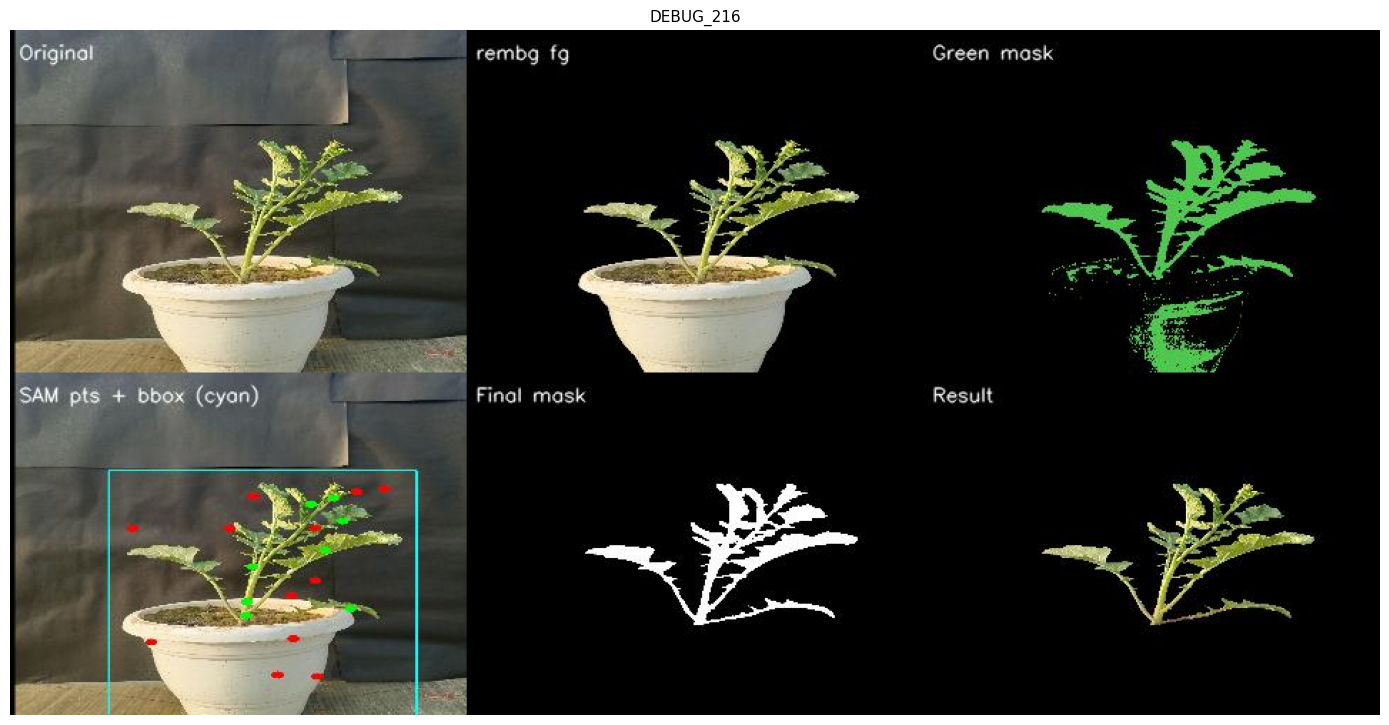

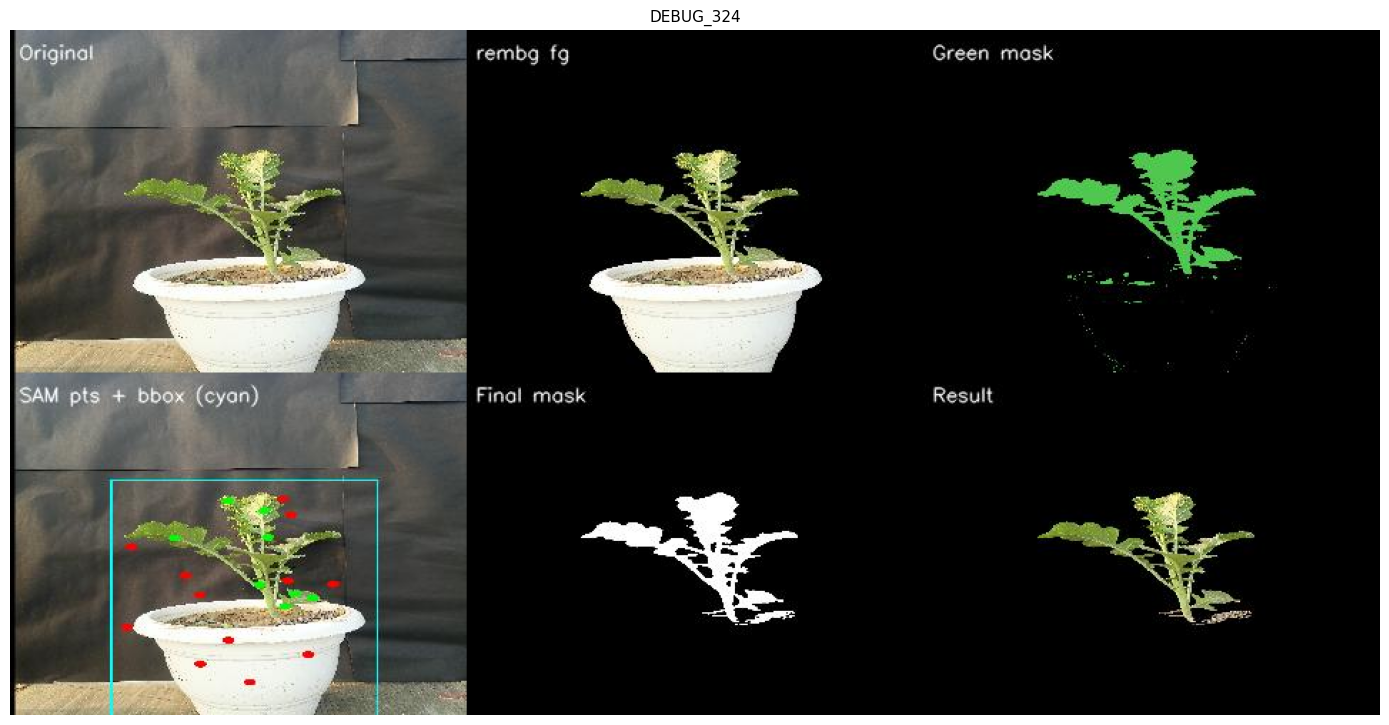

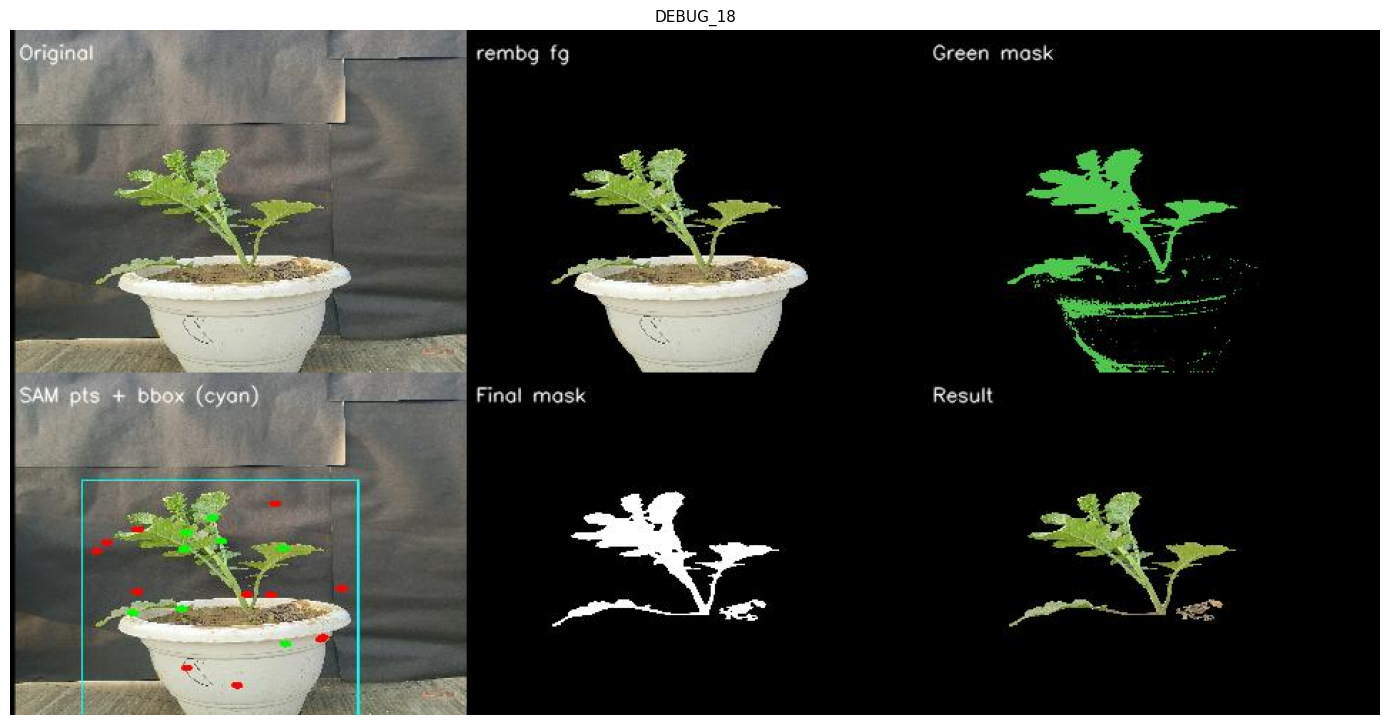

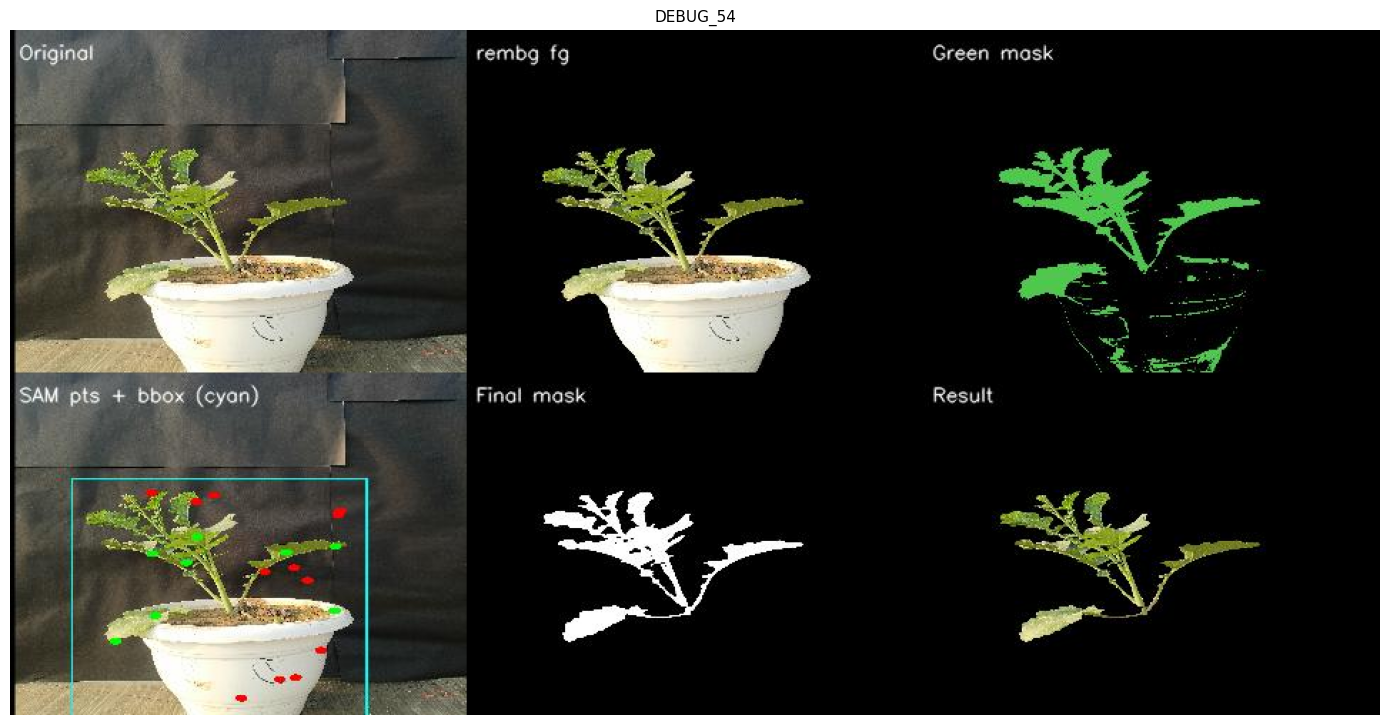

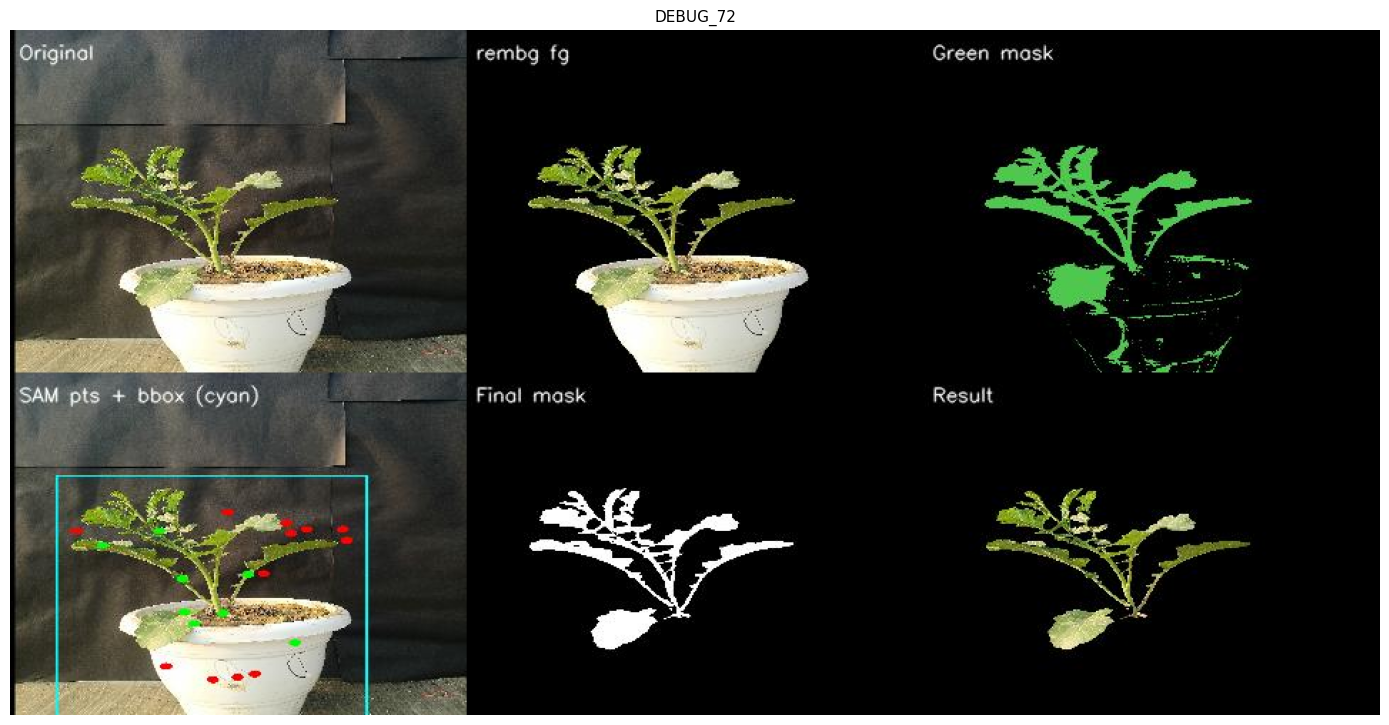

In [ ]:
debug_files = sorted(Path(DEBUG_DIR).glob("DEBUG_*.jpg"))

if not debug_files:
    print("No debug mosaics found. Set SAVE_DEBUG = True and re-run.")
else:
    sample_dbg = random.sample(debug_files, min(5, len(debug_files)))
    for dbg in sample_dbg:
        img = np.array(Image.open(dbg))
        plt.figure(figsize=(14, 9))
        plt.imshow(img)
        plt.title(dbg.stem, fontsize=11)
        plt.axis("off")
        plt.tight_layout()
        plt.show()


In [ ]:
print(f"\nResizing all {cfg.rotation.num_images} images to {cfg.camera.resized_w}x{cfg.camera.resized_h}...")
for view_key in all_views():
    fname = f'{view_key}.png'
    img   = cv2.imread(str(SEGMENTED_DIR / fname))
    if img is None: print(f'  Cannot read {fname}'); continue
    cv2.imwrite(str(RESIZED_DIR / fname),
                cv2.resize(img, (cfg.camera.resized_w, cfg.camera.resized_h), interpolation=cv2.INTER_AREA))
print('Resize done.')


Resizing all 20 images to 400x533...
Resize done.


<div style="width: 100%;">
  <h3><tt>Silhouette extraction</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Using MEAN centroid across all views. Per-image centroid tracks leaf mass distribution which changes with rotation — causing over-correction and inconsistent views.Mean centroid cancels out leaf asymmetry and estimates the true turntable rotation axis.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

Extracting silhouettes (simple threshold)...
                View    Plant px
----------------------------------
               0.png      10,633
             108.png      13,553
             126.png      14,305
             144.png      14,608
             162.png      12,451
              18.png      10,760
             180.png      12,056
             198.png      12,004
             216.png      11,957
             234.png      13,101
             252.png      11,217
             270.png      10,900
             288.png      10,036
             306.png       9,901
             324.png      10,385
             342.png      11,214
              36.png      10,865
              54.png      11,606
              72.png      12,532
              90.png      13,621

Done.


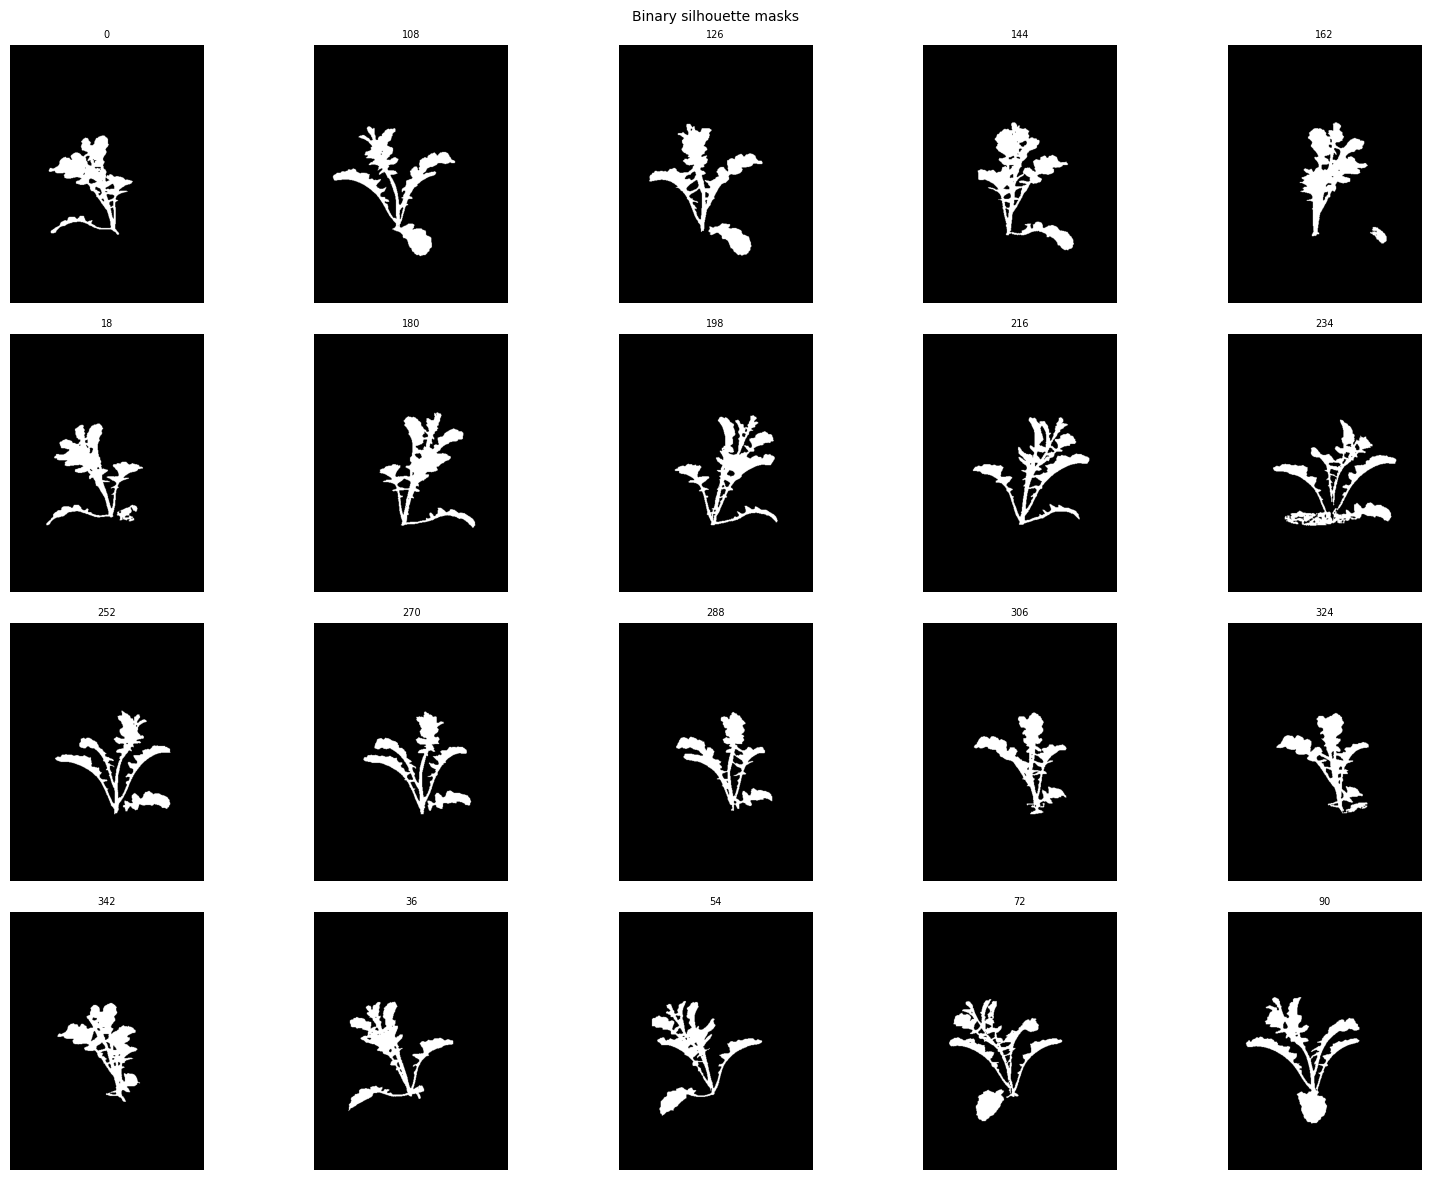

In [ ]:
def extract_silhouette(image_path, threshold=15):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Failed to read image: {image_path}")

    mask = (np.max(img, axis=2) > threshold).astype(np.uint8) * 255
    return mask

image_paths = sorted(RESIZED_DIR.glob("*.png"))

print('Extracting silhouettes (simple threshold)...')
print(f'{"View":>20}  {"Plant px":>10}')
print('-' * 34)

for path in image_paths:
    mask = extract_silhouette(path, threshold=15)

    fname = path.name

    # Save
    cv2.imwrite(str(MASK_DIR / fname), mask)

    # Overlay
    img_vis = cv2.imread(str(path))
    overlay = img_vis.copy()
    overlay[mask > 0] = (0, 200, 0)

    cv2.imwrite(
        str(MASK_VIS_DIR / fname),
        cv2.addWeighted(img_vis, 0.5, overlay, 0.5, 0)
    )

    plant_px = int((mask > 0).sum())
    print(f'{fname:>20}  {plant_px:>10,}')

print('\nDone.')

n_cols = 5
n_rows = math.ceil(len(image_paths) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for idx, path in enumerate(image_paths):
    r, c = divmod(idx, n_cols)
    fname = path.name

    mask_raw = cv2.imread(str(MASK_DIR / fname), cv2.IMREAD_GRAYSCALE)
    axes[r][c].imshow(mask_raw, cmap='gray')
    axes[r][c].set_title(path.stem, fontsize=7)
    axes[r][c].axis('off')

for idx in range(len(image_paths), n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r][c].axis('off')

plt.suptitle('Binary silhouette masks', fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'silhouettes_binary.png'), dpi=150)
plt.show()


<div style="width: 100%;">
  <h3><tt>Pseudo label generation using SAM</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

Generating pseudo-labels...

PSEUDO-LABEL GENERATION
  SAM:  Yes (point-prompted)



Pseudo-labels: 100%|██████████| 20/20 [00:42<00:00,  2.13s/it]



Done in 0.7 min

 view        bg     leaf    stem      pet    apex
--------------------------------------------------
     0   202,567    5,312     750    4,458     113
    18   202,440    5,591     754    4,302     113
    36   202,335    5,318     706    4,728     113
    54   201,594    5,915     729    4,849     113
    72   200,668    5,855      46    6,518     113
    90   199,579    7,616     107    5,785     113
   108   199,647    7,863     115    5,466     109
   126   198,895    8,821      79    5,293     112
   144   198,592    8,179     864    5,452     113
   162   200,749    7,109     384    4,845     113
   180   201,144    6,515     795    4,633     113
   198   201,196    5,703     733    5,455     113
   216   201,243    5,464     696    5,684     113
   234   200,099    5,700       0    7,378      23
   252   201,983    5,526       0    5,665      26
   270   202,300    5,644     508    4,635     113
   288   203,164    5,162     295    4,466     113
   306   203,2

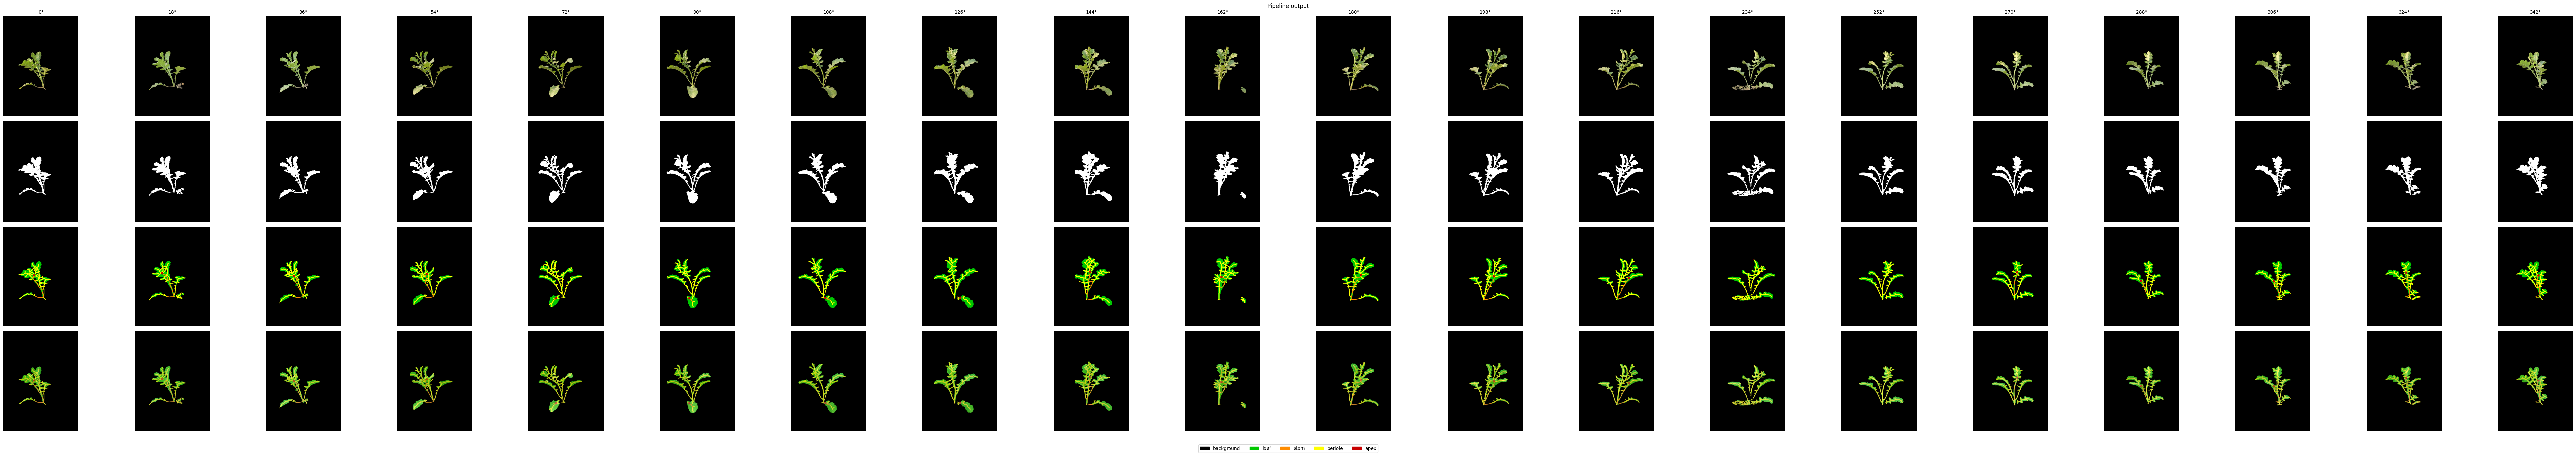

Saved → /content/plant_nerf/checkpoints/pipeline_output.png

Pipeline complete.


In [ ]:
# STEP 1: MORPHOLOGY-BASED PSEUDO-LABEL GENERATION
def get_plant_info(mask):
    rows, cols = np.where(mask > 127)
    H, W = mask.shape
    if len(rows) == 0:
        return dict(found=False, cx=W//2, cy=H//2,
                    rmin=0, rmax=H, cmin=0, cmax=W,
                    pH=H, pW=W, area=0)
    return dict(
        found=True,
        cx=int(cols.mean()), cy=int(rows.mean()),
        rmin=int(rows.min()), rmax=int(rows.max()),
        cmin=int(cols.min()), cmax=int(cols.max()),
        pH=int(rows.max()-rows.min())+1,
        pW=int(cols.max()-cols.min())+1,
        area=len(rows),
    )


def build_skeleton_graph(skel_binary):
    pts = np.argwhere(skel_binary)
    pt_set = set(map(tuple, pts.tolist()))
    G = nx.Graph()
    G.add_nodes_from(map(tuple, pts.tolist()))
    for r, c in pts:
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nb = (r+dr, c+dc)
                if nb in pt_set:
                    G.add_edge((r, c), nb)
    degree = dict(G.degree())
    return G, degree

def find_stem_path(skel_binary, plant, mask_dist):
    H, W = skel_binary.shape
    G, degree = build_skeleton_graph(skel_binary)

    if len(G.nodes) < 4:
        return []

    # Central band to prevent the stem from wandering sideways
    c_half = max(10, int(plant['pW'] * 0.15))
    c_lo   = max(0, plant['cx'] - c_half)
    c_hi   = min(W, plant['cx'] + c_half)

    central_pts = [n for n in G.nodes if c_lo <= n[1] <= c_hi]
    if not central_pts:
        return []

    # Source: Bottom-most central point
    bottom_thresh = plant['rmax'] - int(plant['pH'] * 0.20)
    bottom_pts = [n for n in central_pts if n[0] >= bottom_thresh]
    if not bottom_pts:
        bottom_pts = [max(central_pts, key=lambda p: p[0])]
    src = min(bottom_pts, key=lambda p: abs(p[1] - plant['cx']))

    # Target (Shoot Apex): The thickest branching node in the lower/middle section.
    # We ignore the top 30% of the plant so it doesn't accidentally target a thick upper leaf.
    mid_thresh = plant['rmin'] + int(plant['pH'] * 0.30)
    valid_targets = [n for n in central_pts if n[0] >= mid_thresh]
    if not valid_targets:
        valid_targets = central_pts

    # The true apex/hub is almost always the thickest part of the core plant
    dst = max(valid_targets, key=lambda p: mask_dist[p[0], p[1]])

    try:
        # Heavily penalize horizontal movement to keep the main stem straight
        for u, v in G.edges:
            penalty = abs(u[1] - plant['cx']) + abs(v[1] - plant['cx'])
            G[u][v]['weight'] = 1.0 + penalty * 0.1
        path = nx.shortest_path(G, src, dst, weight='weight')
        return path
    except nx.NetworkXNoPath:
        return []

def find_petiole_paths(skel_binary, stem_path_set, plant, mask_dist):
    H, W = skel_binary.shape

    # Remove the main stem to isolate the branches
    branch_skel = skel_binary.copy()
    for r, c in stem_path_set:
        if 0 <= r < H and 0 <= c < W:
            branch_skel[r, c] = 0

    labeled, n_comp = cc_label(branch_skel, return_num=True)
    petiole_masks = []
    leaf_tip_pts  = []

    for lbl in range(1, n_comp + 1):
        comp_mask = (labeled == lbl)
        pts = np.argwhere(comp_mask)

        # Must be at least a few pixels long to be a valid branch
        if len(pts) < 5:
            continue

        # Check actual thickness instead of aspect ratio (which fails on diagonals)
        mean_thickness = np.mean([mask_dist[r, c] for r, c in pts])

        # A petiole is relatively thin, OR it is a very small connector piece
        is_petiole = (
            mean_thickness < mask_dist.max() * 0.40
            or len(pts) < plant['area'] * 0.05
        )

        if is_petiole:
            petiole_masks.append(comp_mask)

            # The leaf tip is the endpoint FURTHEST outward from the plant's center (cx, cy)
            tip = max(pts, key=lambda p: (p[0] - plant['cy'])**2 + (p[1] - plant['cx'])**2)
            leaf_tip_pts.append((int(tip[0]), int(tip[1])))

    return petiole_masks, leaf_tip_pts

def generate_topview_label(img_path, mask_path):
    """
    Morphology-based pseudo-label for a TOP-DOWN plant image.

    Strategy
    ────────
    1. APEX   (class 4): small circle at the plant centroid — the youngest
                         meristem sits at the rosette centre.
    2. STEM   (class 2): disc of radius ≈ 15% of plant half-width, centred
                         at the centroid — the basal stem hub.
    3. PETIOLE(class 3): skeletonise the remaining (non-stem) plant region;
                         keep only skeleton pixels whose local distance-
                         transform value is < 35% of the max (i.e. thin);
                         dilate slightly.
    4. LEAF   (class 1): all remaining foreground pixels.
    5. BACKGROUND (0)  : black pixels.
    """
    img_full = cv2.imread(str(img_path))
    raw_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = (raw_mask > 10).astype(np.uint8) * 255
    H, W = img_full.shape[:2]

    label_map = np.zeros((H, W), dtype=np.uint8)
    plant = get_plant_info(mask)

    if not plant['found'] or plant['area'] < 50:
        return label_map

    mask_dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    max_dist = float(mask_dist.max()) + 1e-6

    cx, cy = plant['cx'], plant['cy']
    plant_radius = max(plant['pH'], plant['pW']) / 2.0

    # ── STEM: central disc (≈15 % of plant radius) ──────────────────────────
    stem_r = max(8, int(plant_radius * 0.15))
    stem_canvas = np.zeros((H, W), np.uint8)
    cv2.circle(stem_canvas, (cx, cy), stem_r, 255, -1)
    stem_region = (stem_canvas > 0) & (mask > 0)
    label_map[stem_region] = 2

    # ── APEX: very centre (≈5 % of plant radius, overwrites stem centre) ────
    apex_r = max(5, int(plant_radius * 0.05))
    apex_canvas = np.zeros((H, W), np.uint8)
    cv2.circle(apex_canvas, (cx, cy), apex_r, 255, -1)
    label_map[(apex_canvas > 0) & (mask > 0)] = 4

    # ── PETIOLE: thin skeleton branches in the non-stem plant area ───────────
    non_stem_plant = (mask > 0) & ~stem_region
    skel = skeletonize(non_stem_plant.astype(np.uint8)).astype(np.uint8)

    # Retain only thin skeleton pixels (petioles, not thick leaf midribs)
    petiole_skel = np.zeros((H, W), np.uint8)
    ys, xs = np.where(skel > 0)
    for y, x in zip(ys, xs):
        if mask_dist[y, x] < max_dist * 0.35:
            petiole_skel[y, x] = 255

    pet_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    petiole_dil = cv2.dilate(petiole_skel, pet_kernel) > 0
    label_map[petiole_dil & (mask > 0) & (label_map == 0)] = 3

    # ── LEAF: everything else that is plant ──────────────────────────────────
    label_map[(mask > 0) & (label_map == 0)] = 1

    return label_map

def generate_morphology_label(img_path, mask_path):
    img_full  = cv2.imread(str(img_path))
    raw_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = (raw_mask > 10).astype(np.uint8) * 255
    H, W      = img_full.shape[:2]

    plant     = get_plant_info(mask)
    label_map = np.zeros((H, W), dtype=np.uint8)

    if not plant['found'] or plant['area'] < 50:
        return label_map, []

    mask_dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    skel_binary = skeletonize((mask > 0).astype(np.uint8))

    stem_path = find_stem_path(skel_binary, plant, mask_dist)
    stem_path_set = set(map(tuple, stem_path))

    stem_skel_img = np.zeros((H, W), np.uint8)
    for r, c in stem_path:
        if 0 <= r < H and 0 <= c < W:
            stem_skel_img[r, c] = 255

    # stem_thick_px = max(5, int(mask_dist.max() * 0.35))
    stem_thick_px = max(4, min(12, int(mask_dist.max() * 0.15)))
    k_stem = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (stem_thick_px, stem_thick_px))
    stem_region = cv2.dilate(stem_skel_img, k_stem) > 0
    stem_region = stem_region & (mask > 0)
    label_map[stem_region] = 2

    stem_px = np.argwhere(stem_region)
    if len(stem_px) > 0:
        top_idx  = np.argmin(stem_px[:, 0])
        apex_y, apex_x = int(stem_px[top_idx, 0]), int(stem_px[top_idx, 1])
    else:
        apex_y, apex_x = plant['rmin'], plant['cx']
    cv2.circle(label_map, (apex_x, apex_y), radius=6, color=4, thickness=-1)

    petiole_masks, leaf_tip_pts = find_petiole_paths(
        skel_binary, stem_path_set, plant, mask_dist)

    for pm in petiole_masks:
        pm_img = (pm.astype(np.uint8)) * 255
        k_pet  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        pm_dil = cv2.dilate(pm_img, k_pet) > 0
        pm_dil = pm_dil & (mask > 0) & (label_map != 2) & (label_map != 4)
        label_map[pm_dil] = 3

    # All remaining plant pixels → leaf (guaranteed non-empty result)
    label_map[(mask > 0) & (label_map == 0)] = 1

    cv2.circle(label_map, (apex_x, apex_y), radius=6, color=4, thickness=-1)
    label_map[mask == 0] = 0

    return label_map, leaf_tip_pts


# STEP 2: SAM POINT-PROMPTED WITH LEAF BLADE REFINEMENT
def load_sam_predictor(checkpoint_path, device):
    from segment_anything import sam_model_registry, SamPredictor
    sam = sam_model_registry['vit_h'](checkpoint=checkpoint_path)
    sam.to(device)
    print("SAM-H loaded.")
    from segment_anything import SamPredictor
    return SamPredictor(sam)


def refine_leaves_with_sam(img_rgb, label_map, mask, leaf_tip_pts, predictor):
    if not leaf_tip_pts:
        return label_map

    predictor.set_image(img_rgb)
    H, W = label_map.shape

    for tip_r, tip_c in leaf_tip_pts:
        walk_r = max(0, tip_r - 15)
        walk_c = np.clip(tip_c, 0, W-1)
        point_coords = np.array([[walk_c, walk_r]])
        point_labels = np.array([1])

        try:
            masks, scores, _ = predictor.predict(
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True,
            )
            best = masks[np.argmax(scores)]
            # paintable = best & (mask > 0) & \
            #             (label_map != 2) & (label_map != 4)
            paintable = best & (mask > 0) & (label_map != 2) & (label_map != 3) & (label_map != 4)
            label_map[paintable] = 1
        except Exception:
            continue

    label_map[(mask > 0) & (label_map == 0)] = 1
    return label_map

#  PIPELINE (STEP 1 and 2)
def label_to_color(label_map):
    H, W = label_map.shape
    out  = np.zeros((H, W, 3), dtype=np.uint8)
    for cid, bgr in cfg.semantic.class_colors_bgr.items():
        out[label_map == cid] = bgr
    return out

def run_pseudo_label_pipeline(use_sam=True, predictor=None):
    if not use_sam:
        predictor = None

    print(f"\n{'='*60}")
    print(f"PSEUDO-LABEL GENERATION")
    print(f"  SAM:  {'Yes (point-prompted)' if use_sam else 'No (morphology only)'}")
    print(f"{'='*60}\n")

    t0 = time.time()
    stats = {}

    for view_key in tqdm(all_views(), desc="Pseudo-labels"):
        fname     = f"{view_key}.png"
        img_path  = RESIZED_DIR / fname
        mask_path = MASK_DIR / fname

        img_full = cv2.imread(str(img_path))
        raw_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img_full is None or raw_mask is None:
            print(f"  WARNING: missing file for view '{view_key}', skipping")
            continue

        mask    = (raw_mask > 10).astype(np.uint8) * 255
        img_rgb = cv2.cvtColor(img_full, cv2.COLOR_BGR2RGB)

        if view_key == 'top':
            label_map    = generate_topview_label(img_path, mask_path)
            leaf_tip_pts = []
        else:
            label_map, leaf_tip_pts = generate_morphology_label(img_path, mask_path)
            if use_sam and predictor is not None:
                label_map = refine_leaves_with_sam(
                    img_rgb, label_map, mask, leaf_tip_pts, predictor)

        # Save
        np.save(str(LABEL_DIR / f"{view_key}.npy"), label_map)
        cv2.imwrite(str(LABEL_VIS_DIR / fname), label_to_color(label_map))

        classes, counts = np.unique(label_map, return_counts=True)
        stats[view_key] = {cfg.semantic.class_names[c]: int(n)
                           for c, n in zip(classes, counts)}

    elapsed = (time.time() - t0) / 60
    print(f"\nDone in {elapsed:.1f} min\n")

    print(f"{'view':>5}  {'bg':>8} {'leaf':>8} {'stem':>7} {'pet':>8} {'apex':>7}")
    print('-' * 50)
    for vk in all_views():
        if vk not in stats:
            continue
        s = stats[vk]
        print(f" {str(vk):>5}  "
              f"{s.get('background',0):>8,} {s.get('leaf',0):>8,} "
              f"{s.get('stem',0):>7,} {s.get('petiole',0):>8,} "
              f"{s.get('apex',0):>7,}")

    return stats

def visualize_pipeline_output(angles_to_show=None):
    if angles_to_show is None:
        angles_to_show = all_views()[:5]

    fig, axes = plt.subplots(4, len(angles_to_show),
                             figsize=(4 * len(angles_to_show), 14))
    row_labels = ['RGB', 'Silhouette', 'Labels', 'Overlay']

    for i, view_key in enumerate(angles_to_show):
        fname   = f"{view_key}.png"
        orig    = cv2.cvtColor(cv2.imread(str(RESIZED_DIR / fname)),
                               cv2.COLOR_BGR2RGB)
        maskv   = cv2.imread(str(MASK_DIR / fname), cv2.IMREAD_GRAYSCALE)
        lmap    = np.load(str(LABEL_DIR / f"{view_key}.npy"))
        lvis    = cv2.cvtColor(label_to_color(lmap), cv2.COLOR_BGR2RGB)
        overlay = np.clip(orig.astype(float) * 0.5 +
                          lvis.astype(float) * 0.5, 0, 255).astype(np.uint8)

        for row, (data, cm) in enumerate(
                [(orig, None), (maskv, 'gray'), (lvis, None), (overlay, None)]):
            axes[row][i].imshow(data, cmap=cm)
            axes[row][i].axis('off')
            if i == 0:
                axes[row][i].set_ylabel(row_labels[row], fontsize=9)
            if row == 0:
                axes[row][i].set_title(view_label(view_key), fontsize=10)

    handles = [
        mpatches.Patch(
            color=np.array(cfg.semantic.class_colors_bgr[c][::-1]) / 255,
            label=cfg.semantic.class_names[c])
        for c in range(cfg.semantic.num_classes)]
    fig.legend(handles=handles, loc='lower center',
               ncol=cfg.semantic.num_classes, fontsize=10, bbox_to_anchor=(0.5, 0.01))
    plt.suptitle('Pipeline output', fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    out_path = CKPT_DIR / "pipeline_output.png"
    plt.savefig(str(out_path), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out_path}")


print("Generating pseudo-labels...")
stats = run_pseudo_label_pipeline(use_sam=True, predictor=predictor)
visualize_pipeline_output(cfg.rotation.rotation_angles)

print("\nPipeline complete.")


In [ ]:
def visualize_top_view():
    view_key = "top"

    fname = f"{view_key}.png"

    # Safety check
    if not (RESIZED_DIR / fname).exists():
        print("Top image not found.")
        return
    if not (MASK_DIR / fname).exists():
        print("Top mask not found.")
        return
    if not (LABEL_DIR / f"{view_key}.npy").exists():
        print("Top label not found.")
        return

    orig = cv2.cvtColor(
        cv2.imread(str(RESIZED_DIR / fname)),
        cv2.COLOR_BGR2RGB
    )

    maskv = cv2.imread(
        str(MASK_DIR / fname),
        cv2.IMREAD_GRAYSCALE
    )

    lmap = np.load(str(LABEL_DIR / f"{view_key}.npy"))
    lvis = cv2.cvtColor(
        label_to_color(lmap),
        cv2.COLOR_BGR2RGB
    )

    overlay = np.clip(
        orig.astype(float) * 0.5 +
        lvis.astype(float) * 0.5,
        0, 255
    ).astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    row_labels = ["RGB", "Silhouette", "Labels", "Overlay"]

    for ax, data, label in zip(
        axes,
        [orig, maskv, lvis, overlay],
        row_labels
    ):
        if label == "Silhouette":
            ax.imshow(data, cmap="gray")
        else:
            ax.imshow(data)
        ax.axis("off")
        ax.set_title(label, fontsize=10)

    plt.suptitle("Top View Output", fontsize=12)
    plt.tight_layout()
    out_path = CKPT_DIR / "top_view_output.png"
    plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved → {out_path}")

visualize_top_view()

Top image not found.


<div style="width: 100%;">
  <h3><tt>Camera poses for NeRF</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

In [ ]:
def look_at(eye, target=np.zeros(3), up=np.array([0., 1., 0.])):
    fwd = target - eye
    fwd = fwd / np.linalg.norm(fwd)
    right = np.cross(fwd, up)
    right = right / np.linalg.norm(right)
    true_up = np.cross(right, fwd)
    mat = np.eye(4, dtype=np.float32)
    mat[:3, 0] = right
    mat[:3, 1] = true_up
    mat[:3, 2] = -fwd
    mat[:3, 3] = eye
    return mat


def axis_angle_to_matrix(vec: torch.Tensor) -> torch.Tensor:
    """
    Convert axis-angle vectors to rotation matrices.
    vec: [N, 3] or [3]
    """
    single = (vec.ndim == 1)
    if single:
        vec = vec.unsqueeze(0)

    theta = torch.sqrt((vec * vec).sum(dim=-1, keepdim=True) + 1e-8)
    k = vec / theta

    kx, ky, kz = k[:, 0], k[:, 1], k[:, 2]
    zero = torch.zeros_like(kx)
    K = torch.stack([
        torch.stack([zero, -kz, ky], dim=-1),
        torch.stack([kz, zero, -kx], dim=-1),
        torch.stack([-ky, kx, zero], dim=-1),
    ], dim=-2)

    eye = torch.eye(3, device=vec.device, dtype=vec.dtype).unsqueeze(0).expand(vec.shape[0], -1, -1)
    sin_t = torch.sin(theta)[:, None]
    cos_t = torch.cos(theta)[:, None]
    R = eye + sin_t * K + (1.0 - cos_t) * (K @ K)

    small = (theta.squeeze(-1) < 1e-6)
    if small.any():
        R = torch.where(small[:, None, None], eye, R)

    return R[0] if single else R


def all_views():
    keys = list(cfg.rotation.rotation_angles)
    if cfg.rotation.use_top_view:
      keys.append('top')
    return keys


def filter_invalid_views():
    keys = []
    for view_key in all_views():
        fname = view_file_name(view_key)
        img_ok = (RESIZED_DIR / fname).exists()
        mask_ok = (MASK_DIR / fname).exists()
        label_ok = (LABEL_DIR / fname.replace('.png', '.npy')).exists()
        if img_ok and mask_ok and label_ok:
            keys.append(view_key)
    return keys


def view_file_name(view_key):
    return f'{view_key}.png'


def view_label(view_key):
    return 'top' if view_key == 'top' else f'{view_key}°'


def build_initial_poses(plant_target):
    poses = {}
    radius = cfg.camera.camera_radius

    for view_key in filter_invalid_views():
        if view_key == 'top' and cfg.rotation.use_top_view:
            eye = plant_target + np.array([0.0, radius * 1.25, 0.15], dtype=np.float32)
            poses[view_key] = look_at(
                eye,
                target=plant_target,
                up=np.array([0., 0., 1.], dtype=np.float32)
            )
        else:
            ar = math.radians(int(view_key))
            eye = plant_target + np.array([
                radius * math.sin(ar),
                0.0,
                radius * math.cos(ar)
            ], dtype=np.float32)

            poses[view_key] = look_at(eye, target=plant_target)

    return poses

In [ ]:
class PoseRefiner(nn.Module):
    def __init__(self, base_poses: dict):
        super().__init__()
        self.view_keys   = list(filter_invalid_views())
        self.key_to_idx  = {k: i for i, k in enumerate(self.view_keys)}
        self.top_view_exists = 'top' in self.key_to_idx

        base = torch.stack([
            torch.tensor(base_poses[k], dtype=torch.float32)
            for k in self.view_keys
        ], dim=0)

        self.register_buffer('base_poses', base)
        self.register_buffer('base_R', base[:, :3, :3].clone())
        self.register_buffer('base_t', base[:, :3, 3].clone())

        self.delta_rot   = nn.Parameter(torch.randn(len(self.view_keys), 3) * 1e-6)
        self.delta_trans = nn.Parameter(torch.randn(len(self.view_keys), 3) * 1e-6)

        # Softer regularisation weight for top view (uncertain pose → less penalty)
        pose_weights = torch.ones(len(self.view_keys), dtype=torch.float32)
        if self.top_view_exists:
            pose_weights[self.key_to_idx['top']] = 0.25
        self.register_buffer('pose_weights', pose_weights)

    def top_view_regularization(self) -> torch.Tensor:
        """
        L2 regularisation for the top-view pose delta only.
        Used during Phase 2 (top_view_start_iter → pose_start_iter)
        before full pose refinement is active for side views.
        """
        if not self.top_view_exists:
            return torch.tensor(0.0, device=self.delta_rot.device)
        top_idx    = self.key_to_idx['top']
        rot_loss   = (self.delta_rot[top_idx]  ** 2).sum()
        trans_loss = (self.delta_trans[top_idx] ** 2).sum()
        return self.pose_weights[top_idx] * (rot_loss + trans_loss)

    def refined_poses(self):
        delta_R = axis_angle_to_matrix(self.delta_rot)
        R = torch.bmm(self.base_R, delta_R)
        t = self.base_t + torch.einsum('bij,bj->bi', self.base_R, self.delta_trans)
        poses = torch.eye(4, device=R.device, dtype=R.dtype).unsqueeze(0).repeat(R.shape[0], 1, 1)
        poses[:, :3, :3] = R
        poses[:, :3, 3]  = t
        return poses

    def pose_for_key(self, view_key):
        return self.refined_poses()[self.key_to_idx[view_key]]

    def export_pose_dict(self):
        poses_np = self.refined_poses().detach().cpu().numpy()
        return {k: poses_np[i] for k, i in self.key_to_idx.items()}

    def transform_rays(self, rays_o_base, rays_d_base, view_ids):
        base_R  = self.base_R[view_ids]
        base_t  = self.base_t[view_ids]
        delta_R = axis_angle_to_matrix(self.delta_rot[view_ids])
        delta_t = self.delta_trans[view_ids]
        rays_o  = base_t + torch.einsum('bij,bj->bi', base_R, delta_t)
        d_cam   = torch.einsum('bij,bj->bi', base_R.transpose(1, 2), rays_d_base)
        rays_d  = torch.einsum('bij,bjk,bk->bi', base_R, delta_R, d_cam)
        return rays_o, rays_d

    def regularization(self):
        rot_loss   = (self.delta_rot   ** 2).sum(-1)
        trans_loss = (self.delta_trans ** 2).sum(-1)
        return (self.pose_weights * (rot_loss + trans_loss)).mean()

In [ ]:
def save_transforms_json(poses_dict, out_path):
    frames = []
    for view_key in filter_invalid_views():
        if view_key not in poses_dict:
            continue
        frames.append({
            'file_path': f'images_resized/{view_key}.png',
            'transform_matrix': poses_dict[view_key].tolist()
        })

    transform_data = {
                          'camera_model': 'OPENCV',
                          **cfg.camera.nerf_intrinsics,
                          'k1': 0.0, 'k2': 0.0, 'p1': 0.0, 'p2': 0.0,
                          'frames': frames
                      }

    with open(out_path, 'w') as f:
        json.dump(transform_data, f, indent=2)

plant_target = np.array([0,0,0])

poses = build_initial_poses(plant_target)

print('Pose verification — plant_target projected position per view:')
print(f'  {"View":>8}  {"proj_x":>8}  {"proj_y":>8}  {"offset_from_centre":>20}')
for view_key in filter_invalid_views():
    if view_key == 'top':
        continue

    P = poses[view_key]
    R33 = P[:3, :3]
    t = P[:3, 3]
    cam_pos = plant_target - t
    cam_coord = R33.T @ cam_pos
    if cam_coord[2] != 0:
        px_proj = (-cam_coord[0] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_w / 2
        py_proj = (-cam_coord[1] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_h / 2
    else:
        px_proj = py_proj = cfg.camera.resized_w / 2
    off = math.hypot(px_proj - cfg.camera.resized_w/2, py_proj - cfg.camera.resized_h/2)
    print(f'  {str(view_key):>8}  {px_proj:>8.1f}  {py_proj:>8.1f}  {off:>8.2f} px from centre')

save_transforms_json(poses, BASE_DIR / 'transforms.json')

print(f'\\nPoses done. focal={cfg.camera.focal_length:.1f}px')
print(f'Camera target: [{plant_target[0]:+.4f}, {plant_target[1]:+.4f}, {plant_target[2]:+.4f}]')
print(f'Top view enabled: {"yes" if "top" in filter_invalid_views() else "no"}')

Pose verification — plant_target projected position per view:
      View    proj_x    proj_y    offset_from_centre
         0     200.0     266.5      0.00 px from centre
        18     200.0     266.5      0.00 px from centre
        36     200.0     266.5      0.00 px from centre
        54     200.0     266.5      0.00 px from centre
        72     200.0     266.5      0.00 px from centre
        90     200.0     266.5      0.00 px from centre
       108     200.0     266.5      0.00 px from centre
       126     200.0     266.5      0.00 px from centre
       144     200.0     266.5      0.00 px from centre
       162     200.0     266.5      0.00 px from centre
       180     200.0     266.5      0.00 px from centre
       198     200.0     266.5      0.00 px from centre
       216     200.0     266.5      0.00 px from centre
       234     200.0     266.5      0.00 px from centre
       252     200.0     266.5      0.00 px from centre
       270     200.0     266.5      0.00 px f

<div style="width: 100%;">
  <h3><tt>Neural Radiance field Model</tt></h3>
</div>

In [ ]:
class HashEncoding(nn.Module):
    def __init__(self, n_levels=16, n_features=4, log2_table=19,
                 base_res=16, max_res=1024):
        super().__init__()
        self.n_levels   = n_levels
        self.n_features = n_features
        self.table_size = 2 ** log2_table
        self.embeddings = nn.ModuleList([
            nn.Embedding(self.table_size, n_features) for _ in range(n_levels)
        ])
        b = math.exp(math.log(max_res/base_res)/(n_levels-1))
        self.resolutions = [int(base_res*(b**i)) for i in range(n_levels)]
        # Precompute all 8 corner offsets — avoids creating tensors in loop
        corners = torch.tensor(
            [[dx,dy,dz] for dx in [0,1] for dy in [0,1] for dz in [0,1]],
            dtype=torch.long)
        self.register_buffer('corners', corners)
        for emb in self.embeddings:
            nn.init.uniform_(emb.weight, -1e-4, 1e-4)

    @property
    def out_dim(self): return self.n_levels * self.n_features

    def _hash(self, coords):
        # FIX: abs() before % prevents negative indices (was causing CUDA assert)
        primes = [1, 2654435761, 805459861]
        h = torch.zeros(coords.shape[0], dtype=torch.long, device=coords.device)
        for i in range(3): h = h ^ (coords[:,i] * primes[i])
        return h.abs() % self.table_size

    def forward(self, x):
        x = x.clamp(-4.0, 4.0)  # FIX: prevents hash overflow from extreme coords
        out = []
        for lvl, res in enumerate(self.resolutions):
            scaled = x * res
            xi     = torch.floor(scaled).long()           # integer voxel [N,3]
            frac   = (scaled - xi.float()).clamp(0., 1.)  # fractional [N,3]

            # Trilinear weights for 8 corners [N,8] — vectorized, no Python loop
            c  = self.corners                             # [8,3]
            wx = torch.stack([1.-frac[:,0], frac[:,0]], 1)  # [N,2]
            wy = torch.stack([1.-frac[:,1], frac[:,1]], 1)
            wz = torch.stack([1.-frac[:,2], frac[:,2]], 1)
            w  = wx[:,c[:,0]] * wy[:,c[:,1]] * wz[:,c[:,2]]  # [N,8]

            # All 8 corners in one batch [N*8] — single embedding lookup
            cc   = (xi.unsqueeze(1) + c.unsqueeze(0)).reshape(-1, 3)  # [N*8,3]
            idx  = self._hash(cc)                                       # [N*8]
            feat = self.embeddings[lvl](idx).reshape(x.shape[0], 8, self.n_features)  # [N,8,F]
            out.append((w.unsqueeze(-1) * feat).sum(1))                 # [N,F]
        return torch.cat(out, dim=-1)  # [N, n_levels*F]


class SmallDirEnc(nn.Module):
    def __init__(self, num_freqs=4):
        super().__init__()
        self.register_buffer('freqs', 2.**torch.arange(num_freqs, dtype=torch.float32))
    @property
    def out_dim(self): return 3 + 3*2*len(self.freqs)
    def forward(self, x):
        out = [x]
        for f in self.freqs: out += [torch.sin(f*x), torch.cos(f*x)]
        return torch.cat(out, -1)


class SemanticNeRF(nn.Module):
    def __init__(self, num_classes=cfg.semantic.num_classes):
        super().__init__()
        self.hash_enc = HashEncoding()
        self.dir_enc  = SmallDirEnc()
        h = self.hash_enc.out_dim   # 64
        d = self.dir_enc.out_dim    # 27

        self.trunk = nn.Sequential(
            nn.Linear(h,  128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
            nn.Linear(128, 128), nn.SiLU(),
        )
        self.density_head  = nn.Linear(128, 1)
        self.color_head    = nn.Sequential(
            nn.Linear(128 + d, 64), nn.SiLU(),
            nn.Linear(64, 3), nn.Sigmoid()
        )
        self.semantic_head = nn.Sequential(
            nn.Linear(128, 64), nn.SiLU(),
            nn.Linear(64, num_classes)
        )
        nn.init.constant_(self.density_head.bias, -4.0)

        self.register_buffer(
            'current_step',
            torch.tensor(0, dtype=torch.long)
        )
        self.sem_grad_warmup = 2000

    def update_step(self, step: int):
        """Call once per training step, before the forward pass."""
        self.current_step.fill_(step)

    def forward(self, pos, dirs):
      pos_normalized = pos / cfg.plant_bound
      x = self.trunk(self.hash_enc(pos_normalized))
      density = F.softplus(self.density_head(x))
      color = self.color_head(torch.cat([x, self.dir_enc(dirs)], -1))
      semantics = self.semantic_head(x.detach())
      return density, color, semantics

# Discrete volume rendering
def volume_render(density, color, semantics, z_vals, rays_d):
    deltas = torch.cat([
        z_vals[..., 1:] - z_vals[..., :-1],
        (z_vals[..., -1:] - z_vals[..., -2:-1])
    ], dim=-1)

    deltas = deltas * torch.norm(rays_d.unsqueeze(-2), dim=-1)
    alpha = 1. - torch.exp(-density[..., 0] * deltas)
    T = torch.cumprod(
        torch.cat([torch.ones_like(alpha[..., :1]),1. - alpha[..., :-1] + 1e-10],
                  dim=-1), dim=-1)

    weights = alpha * T   # [N, S]
    rgb = (weights.unsqueeze(-1) * color).sum(-2)
    acc = weights.sum(-1, keepdim=True)
    sem_probs = torch.softmax(semantics, dim=-1)
    sem = (weights.unsqueeze(-1) * sem_probs).sum(-2)
    depth = (weights * z_vals).sum(-1, keepdim=True)

    return rgb, acc, sem, depth, weights


def get_rays(H, W, focal, pose):
    i = torch.arange(W, dtype=torch.float32, device=pose.device)
    j = torch.arange(H, dtype=torch.float32, device=pose.device)
    gj, gi = torch.meshgrid(j, i, indexing='ij')
    dirs = torch.stack([(gi-W/2.)/focal, -(gj-H/2.)/focal, -torch.ones_like(gi)], -1)
    rays_d = (dirs[...,None,:] * pose[:3,:3]).sum(-1)
    return pose[:3,3].expand(rays_d.shape), rays_d


def sample_coarse(rays_o, rays_d, near, far, n):
    z = near + (far-near)*torch.linspace(0.,1.,n,device=rays_o.device)
    z = z.expand(rays_o.shape[0], n)
    mids=.5*(z[...,1:]+z[...,:-1])
    z = torch.cat([z[...,:1],mids],-1) + (torch.cat([mids,z[...,-1:]],-1)-torch.cat([z[...,:1],mids],-1))*torch.rand_like(z)
    return rays_o.unsqueeze(-2)+rays_d.unsqueeze(-2)*z.unsqueeze(-1), z


def sample_fine(rays_o, rays_d, z_c, w, n_fine):
    z_mids=.5*(z_c[...,1:]+z_c[...,:-1])
    w_mid =w[...,1:-1]+1e-5
    pdf   =w_mid/w_mid.sum(-1,keepdim=True)
    cdf   =torch.cat([torch.zeros_like(pdf[...,:1]),torch.cumsum(pdf,-1)],-1)
    u     =torch.rand(list(cdf.shape[:-1])+[n_fine],device=cdf.device)
    inds  =torch.searchsorted(cdf.contiguous(),u,right=True)
    below = torch.clamp(inds - 1, min=0); above = torch.clamp(inds, max=cdf.shape[-1] - 1)
    i2    =torch.stack([below,above],-1)
    cdf_g =torch.gather(cdf,-1,i2.view(*i2.shape[:-2],-1)).view(*i2.shape)
    bin_g =torch.gather(z_mids,-1,i2.view(*i2.shape[:-2],-1)).view(*i2.shape)
    denom =cdf_g[...,1]-cdf_g[...,0]
    denom =torch.where(denom<1e-5,torch.ones_like(denom),denom)
    z_f   =bin_g[...,0]+(u-cdf_g[...,0])/denom*(bin_g[...,1]-bin_g[...,0])
    z_all,_=torch.sort(torch.cat([z_c,z_f.detach()],-1),-1)
    return rays_o.unsqueeze(-2)+rays_d.unsqueeze(-2)*z_all.unsqueeze(-1), z_all


n_params = sum(p.numel() for p in SemanticNeRF().parameters())
print(f'SemanticNeRF ready. Parameters: {n_params:,}')
print('Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp')

SemanticNeRF ready. Parameters: 33,631,177
Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp


In [ ]:
class PlantDataset:
    # Notice we DO NOT inherit from torch.utils.data.Dataset anymore

    def __init__(self, view_keys=None):
        """
        view_keys: list of views to load. Defaults to all available views.
        """
        if view_keys is None:
            view_keys = filter_invalid_views()

        self.view_keys = []
        str_poses_keys = [str(k) for k in poses.keys()] # Type-safe pose check

        for view_key in view_keys:
            fname = view_file_name(view_key)
            img_path = RESIZED_DIR / fname
            mask_path = MASK_DIR / fname
            label_path = LABEL_DIR / fname.replace('.png', '.npy')

            if not img_path.exists() or not mask_path.exists() or not label_path.exists():
                print(f'  Skipping missing view files: {view_key}')
                continue
            if str(view_key) not in str_poses_keys:
                print(f'  Skipping view without pose: {view_key}')
                continue

            self.view_keys.append(view_key)

        self.view_to_idx = {k: i for i, k in enumerate(self.view_keys)}

        self.rays_o = []
        self.rays_d = []
        self.ray_view_ids = []
        self.gt_rgb = []
        self.gt_mask = []
        self.gt_sem = []

        H = cfg.camera.resized_h
        W = cfg.camera.resized_w
        print(f'Loading dataset ({len(self.view_keys)} views)...')

        for view_key in tqdm(self.view_keys):
            fname = view_file_name(view_key)

            img = cv2.cvtColor(
                cv2.imread(str(RESIZED_DIR / fname)),
                cv2.COLOR_BGR2RGB
            ).astype(np.float32) / 255.

            mask = (cv2.imread(str(MASK_DIR / fname), cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
            lmap = np.load(str(LABEL_DIR / fname.replace('.png', '.npy'))).astype(np.int64)

            # Ensure we are using the correct key type for the global poses dict
            pose_key = view_key if view_key in poses else str(view_key)
            pose = torch.tensor(poses[pose_key], dtype=torch.float32)

            ro, rd = get_rays(H, W, cfg.camera.focal_length, pose)

            flat_count = ro.reshape(-1, 3).shape[0]
            view_idx = self.view_to_idx[view_key]

            self.rays_o.append(ro.reshape(-1, 3))
            self.rays_d.append(rd.reshape(-1, 3))
            self.ray_view_ids.append(torch.full((flat_count,), view_idx, dtype=torch.long))
            self.gt_rgb.append(torch.tensor(img).reshape(-1, 3))
            self.gt_mask.append(torch.tensor(mask).reshape(-1, 1))
            self.gt_sem.append(torch.tensor(lmap).reshape(-1))

        # Flatten into massive 1D tensors
        self.rays_o = torch.cat(self.rays_o)
        self.rays_d = torch.cat(self.rays_d)
        self.ray_view_ids = torch.cat(self.ray_view_ids)
        self.gt_rgb = torch.cat(self.gt_rgb)
        self.gt_mask = torch.cat(self.gt_mask)
        self.gt_sem = torch.cat(self.gt_sem)

        plant_mask = self.gt_mask.squeeze() > 0.5
        self.plant_idx = plant_mask.nonzero(as_tuple=True)[0]
        self.bg_idx = (~plant_mask).nonzero(as_tuple=True)[0]

        # Cache lengths for fast vectorized sampling
        self.n_total = len(self.rays_o)
        self.n_plant = len(self.plant_idx)
        self.n_bg = len(self.bg_idx)

        print(f'  Total rays : {self.n_total:>12,}')
        print(f'  Plant rays : {self.n_plant:>12,}  ({100*self.n_plant/self.n_total:.1f}%)')
        print(f'  BG rays    : {self.n_bg:>12,}  ({100*self.n_bg/self.n_total:.1f}%)')
        print(f'  Sampling   : 75% plant / 25% background per batch')

        self.plant_bias = 0.75

    def get_batch(self, batch_size: int, device):
        """
        Vectorized sampling: grabs the entire batch simultaneously in C++.
        Transfers immediately to the target device (GPU).
        """
        num_plant = int(batch_size * self.plant_bias)
        num_bg = batch_size - num_plant

        # Safety catch: just in case a bad mask leaves 0 background or 0 plant rays
        if self.n_bg == 0:
            num_plant = batch_size
            num_bg = 0
        elif self.n_plant == 0:
            num_bg = batch_size
            num_plant = 0

        indices = []
        if num_plant > 0:
            rand_plant_indices = torch.randint(0, self.n_plant, (num_plant,))
            indices.append(self.plant_idx[rand_plant_indices])
        if num_bg > 0:
            rand_bg_indices = torch.randint(0, self.n_bg, (num_bg,))
            indices.append(self.bg_idx[rand_bg_indices])

        # Combine plant and bg indices
        batch_idx = torch.cat(indices)

        # Slice all data simultaneously and push to GPU
        return (
            self.rays_o[batch_idx].to(device, non_blocking=True),
            self.rays_d[batch_idx].to(device, non_blocking=True),
            self.ray_view_ids[batch_idx].to(device, non_blocking=True),
            self.gt_rgb[batch_idx].to(device, non_blocking=True),
            self.gt_mask[batch_idx].to(device, non_blocking=True),
            self.gt_sem[batch_idx].to(device, non_blocking=True),
        )

In [ ]:
side_view_keys  = [k for k in all_views()]
all_view_keys   = filter_invalid_views()
top_view_in_data = 'top' in all_view_keys

In [ ]:
print("Poses keys:", poses.keys())
print("Available view keys:", all_view_keys)

Poses keys: dict_keys([0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342])
Available view keys: [0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342]


In [ ]:
dataset = PlantDataset(view_keys=all_view_keys)

print(f'Phase 1 Dataset ready  ({len(side_view_keys)} side views only).')
print(f'  Rays/batch    : {cfg.training.batch_rays:,}')
if top_view_in_data:
    print(f'  Top view will be introduced at step {cfg.loss.top_view_start_iter}')
else:
    print('  ⚠️  No top view found — running side-views-only pipeline')

Loading dataset (20 views)...


100%|██████████| 20/20 [00:00<00:00, 33.45it/s]


  Total rays :    4,264,000
  Plant rays :      237,705  (5.6%)
  BG rays    :    4,026,295  (94.4%)
  Sampling   : 75% plant / 25% background per batch
Phase 1 Dataset ready  (20 side views only).
  Rays/batch    : 4,096
  ⚠️  No top view found — running side-views-only pipeline


<div style="width: 100%;">
  <h3><tt>Training</tt></h3>
</div>

In [ ]:
import gc
import torch

vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

gc.collect()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

Deleted: session
Deleted: predictor
Deleted: img
Deleted: P
Deleted: cam_coord
════════════════════════════════════════
Memory Sweep Complete. Current VRAM:
Allocated: 0.01 GB
Reserved:  0.02 GB
════════════════════════════════════════


In [ ]:
@dataclass
class EarlyStopConfig:
    """Configuration for training convergence and termination criteria."""
    min_iters: int = 4000
    plant_acc: float = 0.88
    bg_acc: float = 0.05
    psnr_min: float = 22.0
    patience: int = 600

class EarlyStopper:
    """
    Tracks convergence metrics and determines if training should stop.
    Encapsulates the state tracking so the training loop remains clean.
    """
    def __init__(self, config: EarlyStopConfig):
        self.config = config
        self.stop_condition_met_at = None
        self.has_stopped = False

    def step(self, current_step: int, plant_acc: float, bg_acc: float, psnr: float) -> bool:
        """
        Evaluates current metrics against the stopping criteria.
        Returns True if training should be halted.
        """
        if current_step < self.config.min_iters:
            return False

        # Check if all convergence criteria are met
        ok = (plant_acc >= self.config.plant_acc and
              bg_acc <= self.config.bg_acc and
              psnr >= self.config.psnr_min)

        if ok:
            if self.stop_condition_met_at is None:
                # Start the patience timer
                self.stop_condition_met_at = current_step
            elif current_step - self.stop_condition_met_at >= self.config.patience:
                # Patience exceeded while criteria remained met
                self.has_stopped = True
                return True
        else:
            # Criteria broken, reset the patience timer
            self.stop_condition_met_at = None

        return False

In [ ]:
def compute_color_loss(rgb_f: torch.Tensor, rgb_c: torch.Tensor, gt_rgb: torch.Tensor) -> torch.Tensor:
    """Standard photometric MSE loss with coarse auxiliary."""
    return (F.mse_loss(rgb_f, gt_rgb) + 0.1 * F.mse_loss(rgb_c, gt_rgb)).float()

def compute_silhouette_loss(acc_f: torch.Tensor,
                            acc_c: torch.Tensor,
                            gt_mask: torch.Tensor) -> torch.Tensor:
    """
    Balanced silhouette BCE loss for NeRF opacity.

    acc_f / acc_c are opacity probabilities in [0, 1],
    so we use BCE on probabilities, but force fp32 because BCE is unsafe
    under autocast/mixed precision.
    """

    def balanced_bce_prob(acc: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        device_type = acc.device.type

        # BCE on probabilities must run outside autocast.
        with torch.amp.autocast(device_type=device_type, enabled=False):
            acc = acc.float().reshape(-1).clamp(1e-4, 1.0 - 1e-4)
            mask = mask.float().reshape(-1)

            loss = F.binary_cross_entropy(
                acc,
                mask,
                reduction="none"
            )

            fg = mask > 0.5
            bg = mask <= 0.5

            zero = acc.new_tensor(0.0)

            fg_loss = loss[fg].mean() if fg.any() else zero
            bg_loss = loss[bg].mean() if bg.any() else zero

            return fg_loss + bg_loss

    return balanced_bce_prob(acc_f, gt_mask) + 0.5 * balanced_bce_prob(acc_c, gt_mask)

def compute_semantic_loss(sem_f: torch.Tensor, sem_c: torch.Tensor, gt_sem: torch.Tensor, gt_mask: torch.Tensor) -> torch.Tensor:
    """Negative Log-Likelihood for 3D point classification, ignoring background."""
    gt_sem_full = gt_sem.squeeze().long().clone()
    bg_mask = (gt_mask.squeeze() < 0.5)
    gt_sem_full[bg_mask] = 0  # Force background points to class 0

    eps = 1e-8
    L_sem_f = F.nll_loss(torch.log(sem_f.clamp(min=eps)), gt_sem_full)
    L_sem_c = F.nll_loss(torch.log(sem_c.clamp(min=eps)), gt_sem_full)
    return (L_sem_f + L_sem_c).float()

def compute_bg_suppression_loss(acc_f: torch.Tensor, acc_c: torch.Tensor, bg_mask: torch.Tensor) -> torch.Tensor:
    """Penalizes opacity in regions where the ground truth mask says empty space."""
    if bg_mask.any():
        return acc_f[bg_mask].mean() + 0.5 * acc_c[bg_mask].mean()
    return torch.tensor(0.0, device=acc_f.device)

def compute_distortion_loss(wf: torch.Tensor, z_f: torch.Tensor, wc: torch.Tensor, z_c: torch.Tensor) -> torch.Tensor:
    """
    Directly computes the Mip-NeRF 360 distortion loss to enforce compact,
    sharp surface geometry along the rays.
    """
    def distortion(w: torch.Tensor, z: torch.Tensor) -> torch.Tensor:
        # Flatten trailing dimensions: w -> [N, S], z -> [N, S]
        w = w.squeeze(-1) if w.dim() > 2 else w
        z = z.squeeze(-1) if z.dim() > 2 else z

        # --- 1. Cross-Term ---
        # Penalizes pairs of weights that are large but physically far apart.
        # Math: sum_i sum_j (w_i * w_j * |z_i - z_j|)
        z_diff = torch.abs(z.unsqueeze(-1) - z.unsqueeze(-2))  # Shape: [N, S, S]
        w_prod = w.unsqueeze(-1) * w.unsqueeze(-2)             # Shape: [N, S, S]
        cross_loss = (w_prod * z_diff).sum(dim=(-2, -1))       # Shape: [N]

        # --- 2. Self-Term ---
        # Penalizes individual intervals that are too wide.
        # Math: 1/3 * sum_i (w_i^2 * delta_z_i)
        # Approximate delta_z (interval width) using adjacent samples
        dz = torch.zeros_like(z)
        dz[..., :-1] = z[..., 1:] - z[..., :-1]
        dz[..., -1] = dz[..., -2]  # Duplicate the last interval for consistency

        self_loss = ((w ** 2) * dz).sum(dim=-1) / 3.0          # Shape: [N]

        # Return the mean distortion across all rays in the batch
        return torch.mean(cross_loss + self_loss)

    # Convert to float32 to prevent half-precision overflow/underflow during squared math
    eps_e = 1e-6
    wf_f32, z_f_f32 = wf.float().clamp(eps_e, 1.0), z_f.float()
    wc_f32, z_c_f32 = wc.float().clamp(eps_e, 1.0), z_c.float()

    # Standard weighting: Fine network gets full loss, coarse gets half
    return distortion(wf_f32, z_f_f32) + 0.5 * distortion(wc_f32, z_c_f32)

In [ ]:
def compute_total_loss(
    preds: Dict[str, torch.Tensor],
    gts:   Dict[str, torch.Tensor],
    step:  int,
    config: 'Config',
    pose_refiner: torch.nn.Module
) -> Tuple[torch.Tensor, Dict[str, float]]:
    """Calculates all losses and applies time-dependent curriculum weighting.

    Three-phase pose curriculum
    ───────────────────────────
    Phase 1  (0 → top_view_start_iter)       : no pose reg
    Phase 2  (top_view_start_iter → pose_start_iter) : top-view pose reg only
    Phase 3  (pose_start_iter → end)         : full pose reg (all views)
    """
    device  = gts['rgb'].device
    bg_mask = (gts['mask'].squeeze() < 0.5)

    L_color = compute_color_loss(preds['rgb_f'], preds['rgb_c'], gts['rgb'])
    L_sil   = compute_silhouette_loss(preds['acc_f'], preds['acc_c'], gts['mask'])
    L_dist  = compute_distortion_loss(preds['wf'], preds['z_f'], preds['wc'], preds['z_c'])
    L_bg    = compute_bg_suppression_loss(preds['acc_f'], preds['acc_c'], bg_mask)
    L_sem   = (compute_semantic_loss(preds['sem_f'], preds['sem_c'], gts['sem'], gts['mask'])
               if step >= config.training.sem_start_iters
               else torch.tensor(0.0, device=device))

    # Phase 2 — top view pose regularisation (top_view_start_iter → pose_start_iter)
    L_top_pose = (
        pose_refiner.top_view_regularization()
        if pose_refiner.top_view_exists
           and config.training.top_view_start_iter <= step < config.training.pose_start_iter
        else torch.tensor(0.0, device=device)
    )
    # Phase 3 — full pose regularisation (all views, pose_start_iter onward)
    L_pose = (pose_refiner.regularization()
              if step >= config.training.pose_start_iter
              else torch.tensor(0.0, device=device))

    # ── Curriculum weights ────────────────────────────────────────────────────
    t_color = min(1.0, step / config.training.color_ramp_iters)
    w_color = 0.05 + 0.95 * t_color

    t_sil = max(0.4, 1.0 - 0.6 * min(1.0, step /
               (config.training.num_iters * config.training.sil_decay_start_pct)))
    w_sil = 2.0 * t_sil

    w_sem = 0.0
    if step >= config.training.sem_start_iters:
        t_sem = max(0.0, min(1.0,
            (step - config.training.sem_start_iters) / config.training.sem_ramp_iters))
        w_sem = config.training.lambda_sem * t_sem

    # Phase 2: ramp in top view pose weight
    w_top_pose = 0.0
    if (pose_refiner.top_view_exists
            and config.training.top_view_start_iter <= step < config.training.pose_start_iter):
        t_top = max(0.0, min(1.0,
            (step - config.training.top_view_start_iter)
            / config.training.top_view_pose_ramp_iters))
        w_top_pose = config.training.lambda_pose * t_top

    # Phase 3: ramp in full (all views) pose weight
    w_pose = 0.0
    if step >= config.training.pose_start_iter:
        t_pose = max(0.0, min(1.0,
            (step - config.training.pose_start_iter) / config.training.pose_ramp_iters))
        w_pose = config.training.lambda_pose * t_pose

    total_loss = (
        (w_color  * L_color)  +
        (w_sil    * L_sil)    +
        (w_sem    * L_sem)    +
        (config.training.lambda_dist    * L_dist)  +
        (config.training.lambda_bg_acc  * L_bg)    +
        (w_top_pose * L_top_pose)  +   # Phase 2: top view pose reg
        (w_pose     * L_pose)          # Phase 3: all view pose reg
    )

    loss_dict = {
        'total':        total_loss.item(),
        'color':        L_color.item(),
        'silhouette':   L_sil.item(),
        'semantic':     L_sem.item(),
        'semantic_w':   float(w_sem * L_sem.item()),
        'distortion':   L_dist.item(),
        'bg_acc':       L_bg.item(),
        'pose':         L_pose.item(),
        'pose_w':       float(w_pose * L_pose.item()),
        'top_pose':     L_top_pose.item(),            # NEW
        'top_pose_w':   float(w_top_pose * L_top_pose.item()),  # NEW
    }

    return total_loss, loss_dict

In [ ]:
early_stop_config = EarlyStopConfig()
early_stopper     = EarlyStopper(early_stop_config)

model        = SemanticNeRF(num_classes=cfg.semantic.num_classes).to(cfg.device)
model        = torch.compile(model)
pose_refiner = PoseRefiner(poses).to(cfg.device)

optimizer = torch.optim.Adam([
    {'params': model.parameters(),        'lr': cfg.training.lr},
    {'params': pose_refiner.parameters(), 'lr': cfg.training.pose_lr},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.training.num_iters, eta_min=cfg.training.lr * 0.01)
scaler = torch.amp.GradScaler('cuda', enabled=cfg.training.use_amp)

history = {k: [] for k in
           ['total', 'color', 'silhouette', 'semantic',
            'distortion', 'bg_acc', 'pose', 'top_pose']}   # top_pose added
early_stopped        = False
stop_condition_met_at = None

step    = 0
pbar    = tqdm(total=cfg.training.num_iters, desc='Training')

while step < cfg.training.num_iters:
    # INTRODCUTION OF TOP VIEW
    if step == cfg.training.top_view_start_iter and top_view_in_data:

        print(f'\n{"═"*60}')
        print(f'Step {step}: PHASE 2 — Top view introduced + top-view pose refinement ON')
        print(f'{"═"*60}')

        dataset = PlantDataset(view_keys=all_view_keys)
        print(f'  Dataset rebuilt: {len(all_view_keys)} views (side + top)')


    rays_o_base, rays_d_base, view_ids, gt_rgb, gt_mask, gt_sem = dataset.get_batch(
        cfg.training.batch_rays,
        device=cfg.device
    )
    bg_mask = (gt_mask.squeeze() < 0.5)

    model.update_step(step)

    if step >= cfg.training.pose_start_iter:
        rays_o, rays_d = pose_refiner.transform_rays(
            rays_o_base, rays_d_base, view_ids)

    elif step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        top_global_id = pose_refiner.key_to_idx['top']
        is_top_ray    = (view_ids == top_global_id)
        if is_top_ray.any():
            rays_o = rays_o_base.clone()
            rays_d = rays_d_base.clone()
            top_ro, top_rd = pose_refiner.transform_rays(
                rays_o_base[is_top_ray],
                rays_d_base[is_top_ray],
                view_ids[is_top_ray],
            )
            rays_o[is_top_ray] = top_ro
            rays_d[is_top_ray] = top_rd
        else:
            rays_o, rays_d = rays_o_base, rays_d_base

    else:
        rays_o, rays_d = rays_o_base, rays_d_base

    with torch.amp.autocast('cuda', enabled=cfg.training.use_amp):
        pts_c, z_c = sample_coarse(
            rays_o, rays_d, cfg.training.near, cfg.training.far,
            cfg.training.n_samples_coarse)
        N, S, _ = pts_c.shape
        dc, cc, sc = model(
            pts_c.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S, 3).reshape(-1, 3))
        rgb_c, acc_c, sem_c, _, wc = volume_render(
            dc.reshape(N, S, 1), cc.reshape(N, S, 3),
            sc.reshape(N, S, cfg.semantic.num_classes), z_c, rays_d)

        pts_f, z_f = sample_fine(rays_o, rays_d, z_c, wc.detach(),
                                 cfg.training.n_samples_fine)
        N, S2, _ = pts_f.shape
        df, cf, sf = model(
            pts_f.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S2, 3).reshape(-1, 3))
        rgb_f, acc_f, sem_f, _, wf = volume_render(
            df.reshape(N, S2, 1), cf.reshape(N, S2, 3),
            sf.reshape(N, S2, cfg.semantic.num_classes), z_f, rays_d)

        preds = {'rgb_f': rgb_f, 'rgb_c': rgb_c,
                 'acc_f': acc_f, 'acc_c': acc_c,
                 'sem_f': sem_f, 'sem_c': sem_c,
                 'wf': wf, 'z_f': z_f, 'wc': wc, 'z_c': z_c}
        gts_d = {'rgb': gt_rgb, 'mask': gt_mask, 'sem': gt_sem}

        loss, loss_log = compute_total_loss(preds, gts_d, step, cfg, pose_refiner)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)

    if step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)
    elif step >= cfg.training.pose_start_iter:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)

    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    for k in history.keys():
        history[k].append(loss_log.get(k, 0.0))

    if step % cfg.training.log_every == 0:
        with torch.no_grad():
            plant_acc_log = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
            bg_acc_log    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 0.0
            psnr_log      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

        print(
            f'Step {step:5d}: loss={loss_log["total"]:.4f} | '
            f'color={loss_log["color"]:.4f}  sil={loss_log["silhouette"]:.4f}  '
            f'sem={loss_log["semantic_w"]:.4f}  dist={loss_log["distortion"]:.4f}  '
            f'bg_acc={bg_acc_log:.3f}  plant_acc={plant_acc_log:.3f}  '
            f'psnr={psnr_log:.1f}dB  '
            f'pose={loss_log["pose_w"]:.5f}  '
            f'top_pose={loss_log["top_pose_w"]:.5f}'    # NEW
        )

        with torch.no_grad():
            max_rot   = pose_refiner.delta_rot.abs().max().item()
            max_trans = pose_refiner.delta_trans.abs().max().item()
            print(f'         > Camera Delta: Rot_max={max_rot:.6f} rad | Trans_max={max_trans:.6f} units')

        if step >= early_stop_config.min_iters:
            with torch.no_grad():
                plant_acc_est = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
                bg_acc_est    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 1.0
                psnr_est      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

            if early_stopper.step(step, plant_acc_est, bg_acc_est, psnr_est):
                print(f'\nEarly stopping triggered at step {step}')
                break

    step += 1
    pbar.update(1)

pbar.close()


Training:   0%|          | 0/10000 [05:04<?, ?it/s]

Training:   0%|          | 1/10000 [00:02<7:18:31,  2.63s/it]

Step     0: loss=9.4783 | color=0.2253  sil=4.6961  sem=0.0000  dist=0.0028  bg_acc=0.050  plant_acc=0.046  psnr=6.9dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000002 rad | Trans_max=0.000003 units



Training:   1%|          | 51/10000 [00:14<38:00,  4.36it/s]

In [ ]:
print(f'History keys: {list(history.keys())}')

History keys: ['total', 'color', 'silhouette', 'semantic', 'distortion', 'bg_acc', 'pose']


In [ ]:

poses = pose_refiner.export_pose_dict()
save_transforms_json(poses, BASE_DIR / 'transforms.json')

with torch.no_grad():
    print('\\nPose deltas after training:')
    for view_key in image_paths:
        idx = pose_refiner.key_to_idx[view_key]
        rot_deg = torch.linalg.norm(pose_refiner.delta_rot[idx]).item() * 180.0 / math.pi
        trans_mag = torch.linalg.norm(pose_refiner.delta_trans[idx]).item()
        print(f'  {str(view_key):>8}: rot≈{rot_deg:6.2f}°  trans≈{trans_mag:7.4f}')

<div style="width: 100%;">
  <h3><tt>Rendering the results</tt></h3>
</div>

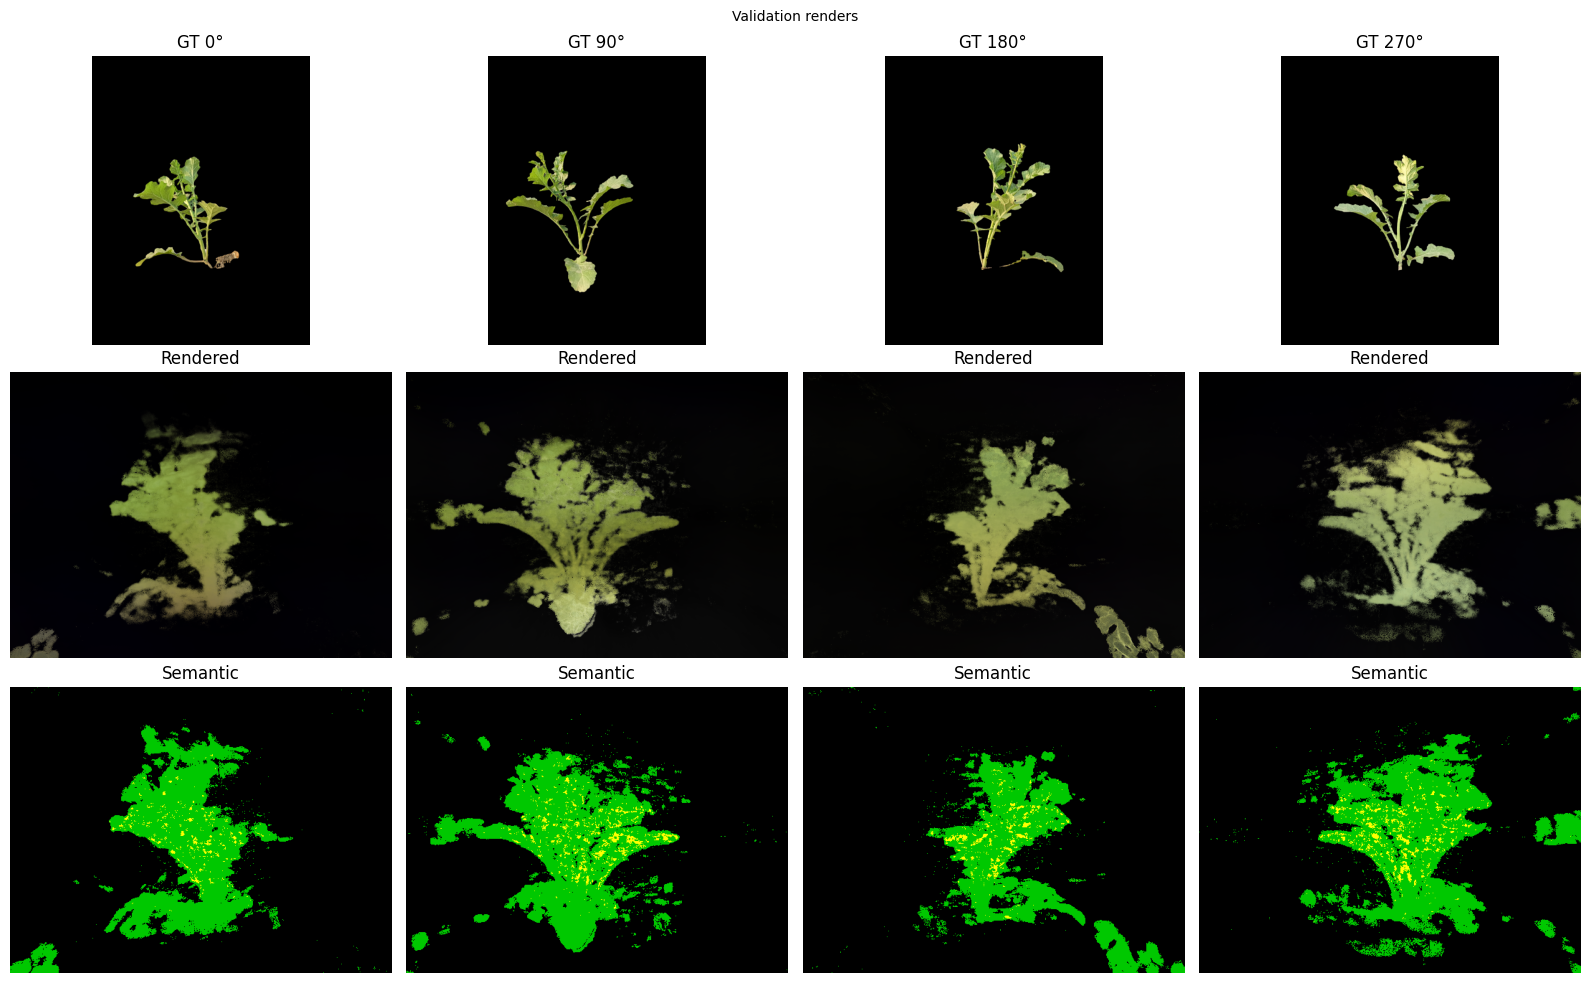

In [ ]:
model.eval()

def render_image(model, pose, H, W, focal, chunk=1024):
    pose_t=torch.tensor(pose,dtype=torch.float32,device=cfg.device)
    ro,rd=get_rays(H,W,focal,pose_t)
    ro_f=ro.reshape(-1,3); rd_f=rd.reshape(-1,3); N=ro_f.shape[0]
    rgbs,accs,sems=[],[],[]
    with torch.no_grad():
        for s in range(0,N,chunk):
            e=min(s+chunk,N); r_o=ro_f[s:e]; r_d=rd_f[s:e]
            pts_c,z_c=sample_coarse(r_o,r_d,cfg.training.near,cfg.training.far,cfg.training.n_samples_coarse)
            n,sc,_=pts_c.shape
            dc,cc,sc2=model(pts_c.reshape(-1,3),r_d.unsqueeze(1).expand(n,sc,3).reshape(-1,3))
            dc=dc.reshape(n,sc,1);cc=cc.reshape(n,sc,3);sc2=sc2.reshape(n,sc,cfg.semantic.num_classes)
            _,_,_,_,wc=volume_render(dc,cc,sc2,z_c,r_d)
            pts_f,z_f=sample_fine(r_o,r_d,z_c,wc,cfg.training.n_samples_fine)
            n,sf,_=pts_f.shape
            df,cf,sf2=model(pts_f.reshape(-1,3),r_d.unsqueeze(1).expand(n,sf,3).reshape(-1,3))
            df=df.reshape(n,sf,1);cf=cf.reshape(n,sf,3);sf2=sf2.reshape(n,sf,cfg.semantic.num_classes)
            rgb,acc,sem,_,_=volume_render(df,cf,sf2,z_f,r_d)
            rgbs.append(rgb.cpu());accs.append(acc.cpu());sems.append(sem.cpu())
    rgb_img=torch.cat(rgbs).reshape(H,W,3).numpy()
    sem_cls=torch.cat(sems).reshape(H,W,cfg.semantic.num_classes).argmax(-1).numpy().astype(np.uint8)
    return rgb_img, sem_cls

# Render 4 test views
fig,axes=plt.subplots(3,4,figsize=(16,10))
for col,angle in enumerate([0,90,180,270]):
    fname=f'{angle}.png'
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/fname)),cv2.COLOR_BGR2RGB)
    rgb_p,sem_p=render_image(model,poses[angle],cfg.camera.resized_w,cfg.camera.resized_h,cfg.camera.focal_length)
    sem_c=np.zeros((*sem_p.shape,3),dtype=np.uint8)
    for cid,bgr in cfg.semantic.class_colors_bgr.items(): sem_c[sem_p==cid]=bgr[::-1]
    axes[0][col].imshow(gt);              axes[0][col].set_title(f'GT {angle}°')
    axes[1][col].imshow(rgb_p.clip(0,1)); axes[1][col].set_title('Rendered')
    axes[2][col].imshow(sem_c);           axes[2][col].set_title('Semantic')
    for r in range(3): axes[r][col].axis('off')
plt.suptitle('Validation renders',fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'validation_renders.png'),dpi=150)
plt.show()

In [ ]:
# PSNR all views
psnrs=[]
for angle in cfg.rotation.rotation_angles:
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/f'{angle}.png')),
                    cv2.COLOR_BGR2RGB).astype(np.float32)/255.
    rgb_p,_=render_image(model,poses[angle],cfg.camera.resized_w,cfg.camera.resized_h,cfg.camera.focal_length)
    psnr=-10*np.log10(np.mean((gt-rgb_p.clip(0,1))**2)+1e-8)
    psnrs.append(psnr)
    print(f'  {angle:3d}°  PSNR={psnr:.2f} dB')
print(f'\nMean PSNR: {np.mean(psnrs):.2f} dB')

<div style="width: 100%;">
  <h3><tt>Novel view synthesis</tt></h3>
</div>

Rendering Novel View... (This might take a few seconds)


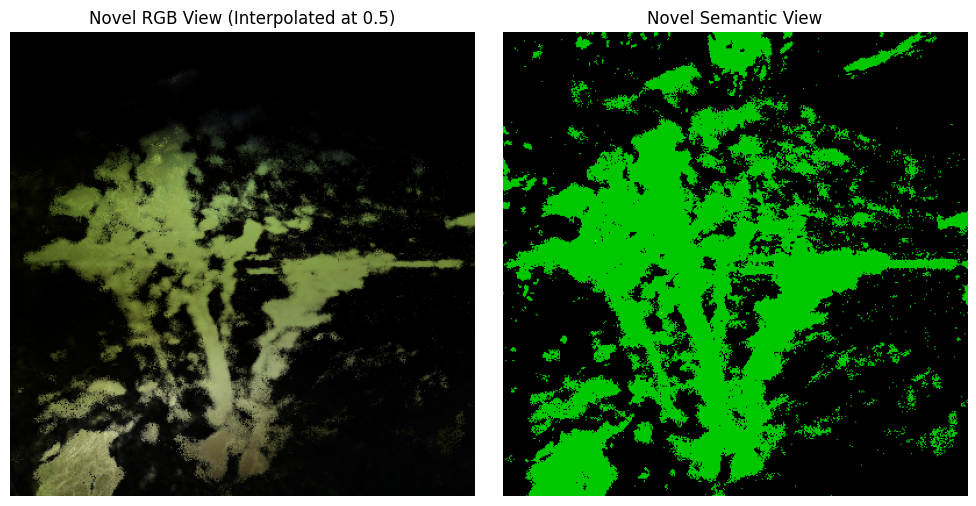

In [ ]:
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp
import numpy as np
import matplotlib.pyplot as plt

# 1. Choose two existing angles to blend between
pose1 = poses[0]   # Camera at 0 degrees
pose2 = poses[90]  # Camera at 90 degrees

# 2. Extract the positions (Translations) and blend them
t1 = pose1[:3, 3]
t2 = pose2[:3, 3]
fraction = 0.5     # 0.5 means exactly halfway! (Try 0.25 or 0.75 later)
t_novel = t1 * (1 - fraction) + t2 * fraction

# 3. Extract the camera angles (Rotations) and mathematically blend them
rotations = R.from_matrix([pose1[:3, :3], pose2[:3, :3]])
slerp = Slerp([0, 1], rotations)
r_novel = slerp([fraction])[0].as_matrix()

# 4. Build our brand new 4x4 Novel Camera Pose
pose_novel = np.eye(4, dtype=np.float32)
pose_novel[:3, :3] = r_novel
pose_novel[:3, 3] = t_novel

print("Rendering Novel View... (This might take a few seconds)")

# 5. Render using your trained NeRF!
rgb_novel, sem_novel = render_image(model, pose_novel, cfg.camera.crop_size, cfg.camera.crop_size, cfg.camera.focal_length)

# 6. Display the result
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(rgb_novel.clip(0, 1))
axes[0].set_title(f'Novel RGB View (Interpolated at {fraction})')
axes[0].axis('off')

# Colorize semantic map
sem_c = np.zeros((*sem_novel.shape, 3), dtype=np.uint8)
for cid, bgr in cfg.semantic.class_colors_bgr.items():
    sem_c[sem_novel == cid] = bgr[::-1]

axes[1].imshow(sem_c)
axes[1].set_title('Novel Semantic View')
axes[1].axis('off')

plt.tight_layout()
plt.show()

<div style="width: 100%;">
  <h3><tt>Mesh Extraction</tt></h3>
</div>

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

════════════════════════════════════════
Memory Sweep Complete. Current VRAM:
Allocated: 0.56 GB
Reserved:  2.05 GB
════════════════════════════════════════


In [ ]:
print('Querying density on 3D voxel grid...')
xs=torch.linspace(-cfg.plant_bound,cfg.plant_bound,cfg.grid_res)
gx,gy,gz=torch.meshgrid(xs,xs,xs,indexing='ij')
pts_flat=torch.stack([gx,gy,gz],-1).reshape(-1,3)
density_vol=np.zeros(cfg.grid_res**3,dtype=np.float32)
sem_vol    =np.zeros(cfg.grid_res**3,dtype=np.uint8)
CHUNK=8192
model.eval()
with torch.no_grad():
    for s in tqdm(range(0,pts_flat.shape[0],CHUNK),desc='Density query'):
        e=min(s+CHUNK,pts_flat.shape[0])
        p=pts_flat[s:e].to(cfg.device); dummy=torch.zeros_like(p)
        den,_,sem=model(p,dummy)
        density_vol[s:e]=den.squeeze(-1).cpu().numpy()
        sem_vol[s:e]=sem.argmax(-1).cpu().numpy().astype(np.uint8)
density_vol=density_vol.reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)
sem_vol    =sem_vol    .reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)

del pts_flat, gx, gy, gz, xs
gc.collect()

print(f'Density: min={density_vol.min():.2f} max={density_vol.max():.2f}')

verts,faces,normals,_=measure.marching_cubes(
    density_vol, level=cfg.density_threshold, spacing=(2*cfg.plant_bound/cfg.grid_res,)*3)
verts -= cfg.plant_bound
print(f'Mesh: {len(verts):,} vertices, {len(faces):,} faces')

def w2v(v,b,r): return ((v+b)/(2*b)*(r-1)).clip(0,r-1).astype(int)
vi=w2v(verts[:,0],cfg.plant_bound,cfg.grid_res)
vj=w2v(verts[:,1],cfg.plant_bound,cfg.grid_res)
vk=w2v(verts[:,2],cfg.plant_bound,cfg.grid_res)
vc=sem_vol[vi,vj,vk]
vcol=np.zeros((len(verts),3),dtype=np.float32)
for cid,bgr in cfg.semantic.class_colors_bgr.items():
    vcol[vc==cid]=np.array(bgr[::-1],np.float32)/255.

del density_vol, sem_vol, vi, vj, vk, vc
gc.collect()

obj_path=OUTPUT_DIR/'plant_3d.obj'
with open(obj_path,'w') as f:
    f.write('# Semantic NeRF Plant\n')
    for v,c in zip(verts,vcol): f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f} {c[0]:.4f} {c[1]:.4f} {c[2]:.4f}\n')
    f.write('\n')
    for face in faces: f.write(f'f {face[0]+1} {face[1]+1} {face[2]+1}\n')
print(f'Saved: {obj_path}')

try:
    import open3d as o3d

    print('\nBuilding raw Open3D mesh...')
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(verts)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(faces)
    o3d_mesh.vertex_colors = o3d.utility.Vector3dVector(vcol)

    del verts, faces, vcol
    gc.collect()

    print('Filtering out floating noise (keeping largest connected component)...')
    triangle_clusters, cluster_n_triangles, cluster_area = o3d_mesh.cluster_connected_triangles()

    triangle_clusters = np.asarray(triangle_clusters)
    cluster_n_triangles = np.asarray(cluster_n_triangles)
    largest_cluster_idx = cluster_n_triangles.argmax()

    triangles_to_remove = triangle_clusters != largest_cluster_idx
    o3d_mesh.remove_triangles_by_mask(triangles_to_remove)
    o3d_mesh.remove_unreferenced_vertices()

    print(f'Cleaned Mesh: {len(o3d_mesh.vertices):,} vertices, {len(o3d_mesh.triangles):,} faces')

    print('Applying Laplacian smoothing...')
    o3d_mesh = o3d_mesh.filter_smooth_laplacian(number_of_iterations=10, lambda_filter=0.5)

    ply_path = str(OUTPUT_DIR / 'plant_3d_clean.ply')
    o3d.io.write_triangle_mesh(ply_path, o3d_mesh)
    print(f'✅ Saved cleaned & smoothed PLY to: {ply_path}')
except Exception as e:
    print(f'Open3D processing failed: {e}. Raw OBJ is still saved.')

Querying density on 3D voxel grid...


Density query: 100%|██████████| 16384/16384 [00:31<00:00, 526.02it/s]


Density: min=0.00 max=110.51
Mesh: 3,252,576 vertices, 6,306,268 faces
Saved: /content/plant_nerf/output/plant_3d.obj

Building raw Open3D mesh...
Filtering out floating noise (keeping largest connected component)...
Cleaned Mesh: 1,329,756 vertices, 2,703,652 faces
Applying Laplacian smoothing...
✅ Saved cleaned & smoothed PLY to: /content/plant_nerf/output/plant_3d_clean.ply


<div style="width: 100%;">
  <h3><tt>Mesh Preview</tt></h3>
</div>

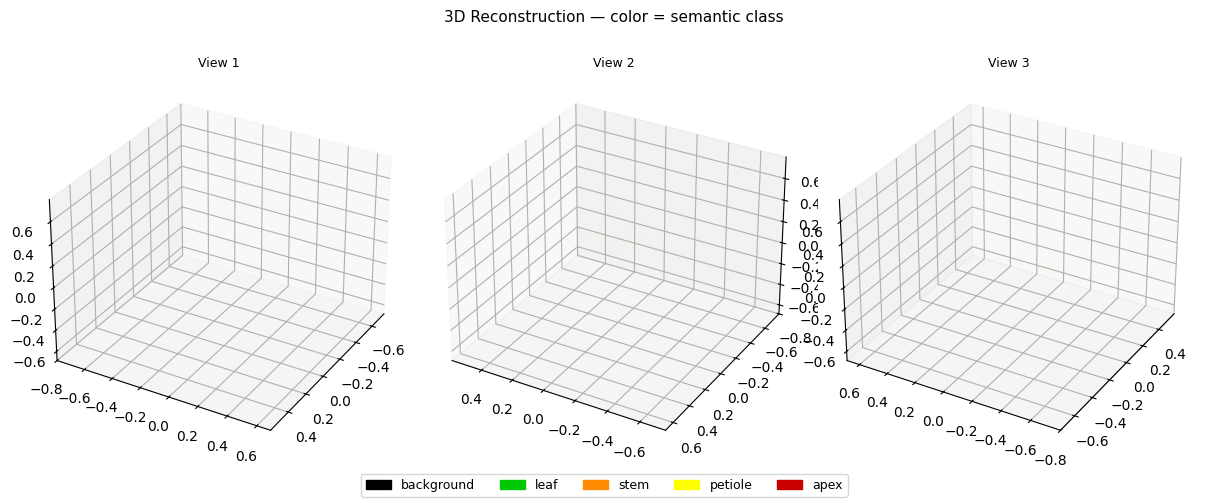

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig=plt.figure(figsize=(12,5))
for idx,(elev,azim) in enumerate([(30,30),(30,120),(30,210)]):
    ax=fig.add_subplot(1,3,idx+1,projection='3d')
    stride=max(1,len(faces)//3000)
    fs=faces[::stride][:3000]
    poly=Poly3DCollection([verts[f] for f in fs],alpha=0.6)
    poly.set_facecolor([[*vcol[f[0]],0.7] for f in fs])
    ax.add_collection3d(poly)
    ax.set_xlim(verts[:,0].min(),verts[:,0].max())
    ax.set_ylim(verts[:,1].min(),verts[:,1].max())
    ax.set_zlim(verts[:,2].min(),verts[:,2].max())
    ax.view_init(elev=elev,azim=azim)
    ax.set_title(f'View {idx+1}',fontsize=9)
handles=[mpatches.Patch(color=np.array(CLASS_COLORS_BGR[c][::-1])/255,label=CLASS_NAMES[c]) for c in CLASS_NAMES]
fig.legend(handles=handles,loc='lower center',ncol=5,fontsize=9)
plt.suptitle('3D Reconstruction — color = semantic class',fontsize=11)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'mesh_preview.png'),dpi=150)
plt.show()

<div style="width: 100%;">
  <h3><tt>Post processing</tt></h3>
</div>

In [ ]:
import open3d as o3d
import numpy as np
from scipy.spatial import ConvexHull, cKDTree

class EnhancedGeometricPhenotyper:
    def __init__(self, filepath):
        self.filepath = filepath
        self.pcd = None
        self.stem_pcd = None
        self.leaf_pcd = None
        self.leaf_clusters = []
        np.random.seed(42) # For consistent sampling across runs

    def run_pipeline(self):
        print("[1/4] Loading and Sampling Point Cloud...")
        mesh = o3d.io.read_triangle_mesh(self.filepath)
        self.pcd = mesh.sample_points_uniformly(number_of_points=200000)

        print("[2/4] Segmenting Stem and Leaves...")
        points = np.asarray(self.pcd.points)

        # Robust Center: Median is less sensitive to leaning canopies than Mean
        center_xy = np.median(points[:, :2], axis=0)
        dist_from_center = np.linalg.norm(points[:, :2] - center_xy, axis=1)
        z_min, z_max = np.min(points[:, 2]), np.max(points[:, 2])

        # Stem = inner 6% of the plant's radial width, plus the very bottom base
        is_stem = (dist_from_center < np.percentile(dist_from_center, 6)) | \
                  (points[:, 2] < z_min + (z_max - z_min) * 0.05)

        self.stem_pcd = self.pcd.select_by_index(np.where(is_stem)[0])
        self.leaf_pcd = self.pcd.select_by_index(np.where(~is_stem)[0])

        print("[3/4] Clustering Leaves via DBSCAN...")
        clean_leaf = self.leaf_pcd.voxel_down_sample(voxel_size=0.008)
        cl, ind = clean_leaf.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.5)
        clean_leaf = clean_leaf.select_by_index(ind)

        # DBSCAN clustering
        labels = np.array(clean_leaf.cluster_dbscan(eps=0.065, min_points=400, print_progress=False))

        self.leaf_clusters = []
        if len(labels) > 0:
            for i in np.unique(labels[labels >= 0]):
                self.leaf_clusters.append(np.asarray(clean_leaf.points)[labels == i])

        self.extract_traits()

    def get_local_stem_vector(self, stem_pts, node_pt, window_size=0.05):
        """Uses PCA to find the direction of the stem near the attachment node."""
        # Get stem points within +/- window_size (e.g., 5cm) of the node's Z height
        local_mask = (stem_pts[:, 2] > node_pt[2] - window_size) & \
                     (stem_pts[:, 2] < node_pt[2] + window_size)
        local_stem_pts = stem_pts[local_mask]

        if len(local_stem_pts) < 10:
            return np.array([0, 0, 1]) # Fallback to vertical if insufficient points

        # Calculate Principal Component (Direction of highest variance = stem direction)
        cov_mat = np.cov(local_stem_pts.T)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        stem_vec = eigenvectors[:, np.argmax(eigenvalues)]

        # Ensure the vector points "upwards" towards the top of the plant
        if stem_vec[2] < 0:
            stem_vec = -stem_vec

        return stem_vec / np.linalg.norm(stem_vec)

    def calculate_true_branch_angles(self, stem_pts):
        angles = []
        # Use KDTree for lightning-fast closest-point distance calculations
        if len(stem_pts) == 0:
            return []
        stem_tree = cKDTree(stem_pts)

        for cluster in self.leaf_clusters:
            # 1. Find exact attachment Node using KDTree to find closest stem point
            dists_to_stem, nearest_stem_idxs = stem_tree.query(cluster)
            node_idx = np.argmin(dists_to_stem)
            node_pt = cluster[node_idx]

            # 2. Calculate the LOCAL stem direction at this specific node
            stem_vec = self.get_local_stem_vector(stem_pts, node_pt)

            # 3. Get the 'Straightened' base segment of the leaf (nearest 3cm to node)
            local_leaf_mask = np.linalg.norm(cluster - node_pt, axis=1) < 0.03
            base_segment = cluster[local_leaf_mask]

            if len(base_segment) > 5:
                seg_centroid = np.mean(base_segment, axis=0)

                # Vector representing the branch exit direction
                branch_vec = seg_centroid - node_pt
                branch_vec = branch_vec / np.linalg.norm(branch_vec)

                # 4. True Angle Calculation (Dot Product)
                # Clip between -1 and 1 to prevent floating point domain errors in arccos
                dot_product = np.clip(np.dot(stem_vec, branch_vec), -1.0, 1.0)
                angle = np.degrees(np.arccos(dot_product))
                angles.append(angle)

        return angles

    def extract_traits(self):
        print("[4/4] Extracting Biological Traits...")
        traits = {}
        all_pts = np.asarray(self.pcd.points)
        stem_pts = np.asarray(self.stem_pcd.points)

        # ---------------------------------------------------------
        # 1. ROBUST PLANT HEIGHT
        # ---------------------------------------------------------
        # Using 99.5th and 0.5th percentiles ignores stray floating points
        z_max_robust = np.percentile(all_pts[:, 2], 99.5)
        z_min_robust = np.percentile(all_pts[:, 2], 0.5)
        traits['Robust Plant Height (m)'] = z_max_robust - z_min_robust
        traits['Total Leaves'] = len(self.leaf_clusters)

        # ---------------------------------------------------------
        # 2. CANOPY VOXEL VOLUME (Better than Convex Hull)
        # ---------------------------------------------------------
        if len(self.leaf_pcd.points) > 100:
            # Create a voxel grid with 1cm cubes
            voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(self.leaf_pcd, voxel_size=0.01)
            # Volume = number of voxels * volume of one voxel
            traits['Canopy Voxel Volume (m³)'] = len(voxel_grid.get_voxels()) * (0.01 ** 3)

        # ---------------------------------------------------------
        # 3. REFINED STEM DIAMETER
        # ---------------------------------------------------------
        if len(stem_pts) > 10:
            z_slice = np.percentile(stem_pts[:, 2], 20) # Measure at bottom 20%
            # Thinner slice (1cm total) to prevent elliptical stretching on leaning stems
            slice_mask = (stem_pts[:, 2] > z_slice - 0.005) & (stem_pts[:, 2] < z_slice + 0.005)
            slice_pts = stem_pts[slice_mask][:, :2]

            if len(slice_pts) > 3:
                try:
                    hull_2d = ConvexHull(slice_pts)
                    # Instead of Perimeter/Pi, calculate diameter directly from the Area
                    # Area = Pi * (D/2)^2  =>  D = 2 * sqrt(Area / Pi)
                    traits['Stem Diameter (m)'] = 2 * np.sqrt(hull_2d.volume / np.pi)
                    traits['Stem Cross-Section Area (m²)'] = hull_2d.volume
                except Exception:
                    traits['Stem Diameter (m)'] = "Error (Collinear)"

        # ---------------------------------------------------------
        # 4. INDIVIDUAL LEAF AREAS via PCA Projection
        # ---------------------------------------------------------
        leaf_areas = []
        for cluster in self.leaf_clusters:
            if len(cluster) > 10:
                # Use PCA to find the flat plane of the leaf
                cov_mat = np.cov(cluster.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
                # Project points onto the two largest principal components (flattening the leaf)
                flat_leaf = np.dot(cluster - np.mean(cluster, axis=0), eigenvectors[:, 1:])

                try:
                    # The area of the 2D convex hull of the flattened leaf
                    leaf_area = ConvexHull(flat_leaf).volume
                    leaf_areas.append(leaf_area)
                except Exception:
                    continue

        if leaf_areas:
            traits['Average Leaf Area (m²)'] = np.mean(leaf_areas)
            traits['Total Foliage Area (m²)'] = np.sum(leaf_areas)

        # ... (Include the branch angle logic from the previous step here) ...
        # Angle logic
        leaf_angles = self.calculate_true_branch_angles(stem_pts)
        if leaf_angles:
            traits['Average Branch Angle (°)'] = np.mean(leaf_angles)

        # Print Output
        print("\n" + "="*50)
        print(" " * 10 + "REFINED PHENOTYPIC REPORT")
        print("="*50)
        for k, v in traits.items():
            if isinstance(v, float):
                print(f"{k:35}: {v:.6f}")
            else:
                print(f"{k:35}: {v}")

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

════════════════════════════════════════
Memory Sweep Complete. Current VRAM:
Allocated: 0.56 GB
Reserved:  2.05 GB
════════════════════════════════════════


In [ ]:
pheno = ProtractorAlignedPhenotyper("/content/plant_nerf/output/plant_3d_clean.ply")
pheno.run_pipeline()


      STRAIGHTENED PHENOTYPIC REPORT
Plant Height        : 1.324032
Total Leaves        : 9.000000
Stem Perimeter      : 0.339669
Stem Diameter       : 0.108120
----------------------------------------
 INDIVIDUAL BRANCH ANGLES (FROM STEM)
----------------------------------------
Leaf 1 Angle    : 74.5125°
Leaf 2 Angle    : 87.7425°
Leaf 3 Angle    : 82.8024°
Leaf 4 Angle    : 71.0979°
Leaf 5 Angle    : 75.5078°
Leaf 6 Angle    : 62.8769°
Leaf 7 Angle    : 80.2561°
Leaf 8 Angle    : 80.9806°
Leaf 9 Angle    : 79.4197°


<div style="width: 100%;">
  <h3><tt>Saving results</tt></h3>
</div>

In [ ]:
# CELL 15 — DOWNLOAD RESULTS
from google.colab import files
zip_path='/content/plant_nerf_results.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in OUTPUT_DIR.glob('*'): zf.write(str(f),f'output/{f.name}')
    # zf.write(str(CKPT_DIR/'model_final.pt'),'model_final.pt')
print(f'Zip: {zip_path}')
files.download(zip_path)

Zip: /content/plant_nerf_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Hello")

Hello
